# **Phần I. TIỀN XỬ LÝ DỮ LIỆU**

In [99]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score

##1.1 Tổng quan về bộ dữ liệu

 Đọc dữ liệu từ file CSV và hiện thị 5 dòng đầu bộ data

In [100]:
file_path = '/content/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(file_path)
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


**Giải thích ý nghĩa 17 thuộc tính trong dữ liệu**
1. Gender: Giới tính của bệnh nhân.
2. Age : Tuổi của bênh nhân.
3. Height: Chiều cao của bênh nhân.
4. Weight: Cân nặng của bênh nhân.
5. family_history_with_overweight: Người thân trong gia đình có tiền sử béo phì không?
6. FAVC(Frequent consumption of high caloric food): Có thường xuyên ăn đồ ăn giàu năng lượng không?
7. FCVC(Frequency of Consumption of Vegetables): Có thường xuyên ăn rau, củ,... không?
8. NCP(Number of Main Meals): ăn bao nhiêu bữa mỗi ngày
9. CAEC(Consumption of Food Between Meals): Có ăn thêm đồ gì trong bữa ăn không?
10. SMOKE: Bệnh nhân có hút/không hút thuốc.
11. CH2O(Consumption of Water): Có thường xuyên uống nước không?
12. SCC(Calories Monitoring): Có tự giám sát lượng calories hằng ngày không?
13. FAF(Physical Activity Frequency): Có thường xuyên tập thể dục không?
14. TUE(Time Using Technology Devices): Có sử dụng nhiều thiết bị thông minh không?
16. CALC (Alcohol Consumption): Có thường xuyên uống rượu không?
17. MTRANS(Mode of Transportation): Phương tiện di chuyển hằng ngày
18. NObeyesdad: biến mục tiêu gồm 7 loại béo phì

Những thuộc tính này thường được sử dụng để phân tích và chẩn đoán béo phì ở mỗi bệnh nhân, đặc biệt trong việc phân biệt giữa các cấp độ béo phì dựa trên đặc điểm cơ thể, thói quen sinh hoạt hằng ngày của bệnh nhân.




Hiển thị kích thước của bảng dữ liệu

In [101]:
df.shape

(2111, 17)

Hiển thị thông tin tóm tắt về DataFrame df. Cụ thể cung cấp các thông tin sau:

1. Số hàng và số cột của df
2. Tên cột và loại dữ liệu tương ứng của từng cột
3. Số lượng giá trị không bị thiếu của từng cột
4. Tổng dung lượng bộ nhớ mà df sử dụng

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

Lệnh **df.isna().sum()** trong pandas được sử dụng để kiểm tra số lượng giá trị bị thiếu (NaN - Not a Number) trong mỗi cột của DataFrame df. Cụ thể:

df.isna(): Trả về một DataFrame với các giá

*   **df.isna()**: Trả về một DataFrame với các giá trị boolean, trong đó True chỉ ra giá trị bị thiếu (NaN) và False chỉ ra giá trị không bị thiếu.
*   **sum()**: Tổng hợp số lượng giá trị True (giá trị bị thiếu) trong mỗi cột. Kết quả là một danh sách cho biết số lượng giá trị thiếu trong từng cột của DataFrame.

In [103]:
df.isna().sum()

,0
Age,0
Gender,0
Height,0
Weight,0
CALC,0
FAVC,0
FCVC,0
NCP,0
SCC,0
SMOKE,0


Lệnh **df['NObeyesdad'].value_counts()** trong pandas được sử dụng để đếm số lượng các giá trị khác nhau trong cột NObeyesdad của DataFrame df.

 lệnh này sẽ trả về số lượng các mẫu tương ứng cho mỗi loại chẩn đoán. Kết quả sẽ là một bảng liệt kê số lượng các giá trị xuất hiện trong cột, giúp bạn hiểu rõ sự phân bố của các nhãn chẩn đoán trong dữ liệu.

In [104]:
print(df['NObeyesdad'].value_counts())
df['NObeyesdad'].value_counts(True)

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


,proportion
NObeyesdad,
Obesity_Type_I,0.166272
Obesity_Type_III,0.153482
Obesity_Type_II,0.140692
Overweight_Level_I,0.137376
Overweight_Level_II,0.137376
Normal_Weight,0.135955
Insufficient_Weight,0.128849


##1.2 Mã hóa dữ liệu

### Sử dụng Binary Encoding để mã hóa các đặc trưng FAVC, SCC, SMOKE, family_history_with_overweight, Gender


Các đặc trưng FAVC, SCC, SMOKE và family_history_with_overweight được mã hóa bằng phương pháp Binary Encoding vì chúng chỉ chứa hai giá trị phân loại dạng Yes/No và female/mal. Việc sử dụng Binary Encoding giúp chuyển đổi dữ liệu sang dạng số một cách đơn giản, đồng thời vẫn giữ nguyên ý nghĩa của từng đặc trưng.

In [105]:
df[['FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight']].head()

,FAVC,SCC,SMOKE,family_history_with_overweight
0,no,no,no,yes
1,no,yes,yes,yes
2,no,no,no,yes
3,no,no,no,no
4,no,no,no,no


In [106]:
binary_cols = ['FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'Gender']

binary_mapping = {
    'yes': 1, 'no': 0,
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
}

for col in binary_cols:
    df[col] = df[col].map(binary_mapping)

df[['FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight']].head()

,FAVC,SCC,SMOKE,family_history_with_overweight
0,0,0,0,1
1,0,1,1,1
2,0,0,0,1
3,0,0,0,0
4,0,0,0,0


### Sử dụng Ordinal Encoding để mã hóa các đặc trưng MTRANS,CALC, CAEC và NObeyesdad


Các đặc trưng MTRANS, CALC, CAEC và biến mục tiêu NObeyesdad được mã hóa bằng phương pháp Ordinal Encoding do các giá trị của chúng mang tính chất thứ bậc và có thể sắp xếp theo một mức độ nhất định.
- Đối với đặc trưng MTRANS, các giá trị gồm 'Walking', 'Bike', 'Public_Transportation', 'Motorbike', 'Automobile' được sắp xếp từ 0(thấp) → 4(cao) dựa trên mức độ tiêu hao năng lượng của cơ thể khi di chuyển, trong đó Walking tiêu tốn nhiều năng lượng nhất và Automobile tiêu tốn ít nhất.
- Đối với CALC và CAEC, các giá trị 'no', 'Sometimes', 'Frequently', 'Always' thể hiện mức độ tần suất tăng dần nên phù hợp để mã hóa theo thứ tự.
- Biến mục tiêu NObeyesdad gồm các mức 'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', được sắp xếp theo mức độ tăng dần của tình trạng cân nặng và béo phì.

In [107]:
df[['MTRANS', 'CALC', 'CAEC', 'NObeyesdad']].head()

,MTRANS,CALC,CAEC,NObeyesdad
0,Public_Transportation,no,Sometimes,Normal_Weight
1,Public_Transportation,Sometimes,Sometimes,Normal_Weight
2,Public_Transportation,Frequently,Sometimes,Normal_Weight
3,Walking,Frequently,Sometimes,Overweight_Level_I
4,Public_Transportation,Sometimes,Sometimes,Overweight_Level_II


In [108]:
# MTRANS
mtrans_map = {
    'Automobile': 4,
    'Motorbike': 3,
    'Public_Transportation': 2,
    'Walking': 1,
    'Bike': 0
}
df['MTRANS'] = df['MTRANS'].map(mtrans_map)

# CALC, CAEC
ordinal_map = {
    'no': 3,
    'Sometimes': 2,
    'Frequently': 1,
    'Always': 0
}
df['CALC'] = df['CALC'].map(ordinal_map)
df['CAEC'] = df['CAEC'].map(ordinal_map)

# TARGET
target_map = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
df['NObeyesdad'] = df['NObeyesdad'].map(target_map)
df[['MTRANS', 'CALC', 'CAEC', 'NObeyesdad']].head()

,MTRANS,CALC,CAEC,NObeyesdad
0,2,3,2,1
1,2,2,2,1
2,2,1,2,1
3,1,1,2,2
4,2,2,2,3


dữ liệu sau khi đã mã hóa xong

In [109]:
data_encoded = df.copy()
data_encoded.to_csv('obesity_encoded.csv', index=False)
data_encoded.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,0,1.62,64.0,3,0,2.0,3.0,0,0,2.0,1,0.0,1.0,2,2,1
1,21.0,0,1.52,56.0,2,0,3.0,3.0,1,1,3.0,1,3.0,0.0,2,2,1
2,23.0,1,1.80,77.0,1,0,2.0,3.0,0,0,2.0,1,2.0,1.0,2,2,1
3,27.0,1,1.80,87.0,1,0,3.0,3.0,0,0,2.0,0,2.0,0.0,2,1,2
4,22.0,1,1.78,89.8,2,0,2.0,1.0,0,0,2.0,0,0.0,0.0,2,2,3


#**Phần II. GIẢM CHIỀU VÀ TRỰC QUAN HÓA DỮ LIỆU**



##2.1 Chia tập training set (tập huấn luyện) và testing set (tập thử)

In [110]:
encoded = pd.read_csv("/content/obesity_encoded.csv")
X = encoded.drop(['NObeyesdad'], axis=1)
y = encoded['NObeyesdad']

Chia dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (test set)

train_test_split: Đây là hàm từ thư viện scikit-learn, được sử dụng để chia tập dữ liệu thành hai phần: tập huấn luyện và tập kiểm tra.

test_size=0.3:
*   test_size chỉ định tỷ lệ dữ liệu sẽ được dùng làm tập kiểm tra.
*   Ở đây, test_size=0.3 có nghĩa là 30% dữ liệu sẽ được sử dụng cho tập kiểm tra, và 80% dữ liệu còn lại sẽ được dùng cho tập huấn luyện.

random_state=42:
*   random_state là một tham số được sử dụng để đảm bảo tính tái lập (reproducibility).
*   Khi ta thiết lập random_state=42, việc chia dữ liệu sẽ luôn tạo ra cùng một kết quả mỗi khi bạn chạy mã, đảm bảo kết quả là nhất quán khi bạn thử lại.
*   Giá trị 42 không có ý nghĩa đặc biệt, nó chỉ là một số được dùng làm hạt ngẫu nhiên (random seed).

stratify=y:
*   Tác dụng của nó là chia đều tỉ lệ cho cả các mẫu dữ liệu nhãn M và nhãn B.

Kết quả của train_test_split: Hàm này trả về bốn biến:

*   X_train: Tập đặc trưng huấn luyện, chứa 70% của X: gồm 70% mẫu dữ liệu của nhãn M, 70% mẫu dữ liệu của nhãn B.
*   X_test: Tập đặc trưng kiểm tra, chứa 30% của X: gồm 30% mẫu dữ liệu của nhãn M, 30% mẫu dữ liệu của nhãn B.
*   y_train: Tập nhãn huấn luyện, chứa 70% của y: là nhãn của X_train, tỷ lệ như trên.
*   y_test: Tập nhãn kiểm tra, chứa 30% của y.

In [111]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#xuất file csv
x_train.to_csv("X_train.csv", index=False)
x_test.to_csv("X_test.csv", index=False)
y_train.to_frame("NObeyesdad").to_csv("y_train.csv", index=False)
y_test.to_frame("NObeyesdad").to_csv("y_test.csv", index=False)

##2.2 Chuẩn hóa dữ liệu


Việc chuẩn hóa dữ liệu là một bước cực kỳ quan trọng trước khi áp dụng các phương pháp giảm chiều dữ liệu. Nếu các đặc trưng có thang đo khác nhau (ví dụ: một biến từ 0–1, biến khác từ 0–1000), mô hình sẽ bị “thiên vị” về những biến có giá trị lớn hơn, dẫn đến kết quả sai lệch. Sử dụng các phương pháp như StandardScaler giúp đưa dữ liệu về phân phối chuẩn với trung bình bằng 0 và độ lệch chuẩn bằng 1, từ đó cải thiện tốc độ hội tụ và độ chính xác của mô hình. Trong khi đó, RobustScaler lại là lựa chọn tốt hơn khi dữ liệu chứa nhiều outlier, vì nó sử dụng median và IQR (khoảng tứ phân vị) thay vì mean và standard deviation, giúp giảm ảnh hưởng của các giá trị ngoại lai. Việc chọn đúng phương pháp chuẩn hóa không chỉ giúp mô hình học tốt hơn mà còn đảm bảo tính ổn định và khả năng tổng quát hóa trên dữ liệu mới.

Để quyết định nên dùng phương pháp chuẩn hóa nào tốt nhất cho từng biến, ta sẽ đánh giá skew và outlier của các feature cần chuẩn hóa.

tuy nhiên các đặc trưng được mã hóa bằng Binary Encoding và Ordinal Encoding chủ yếu mang tính chất phân loại rời rạc với miền giá trị nhỏ, do đó nhóm sử dụng StandardScaler.

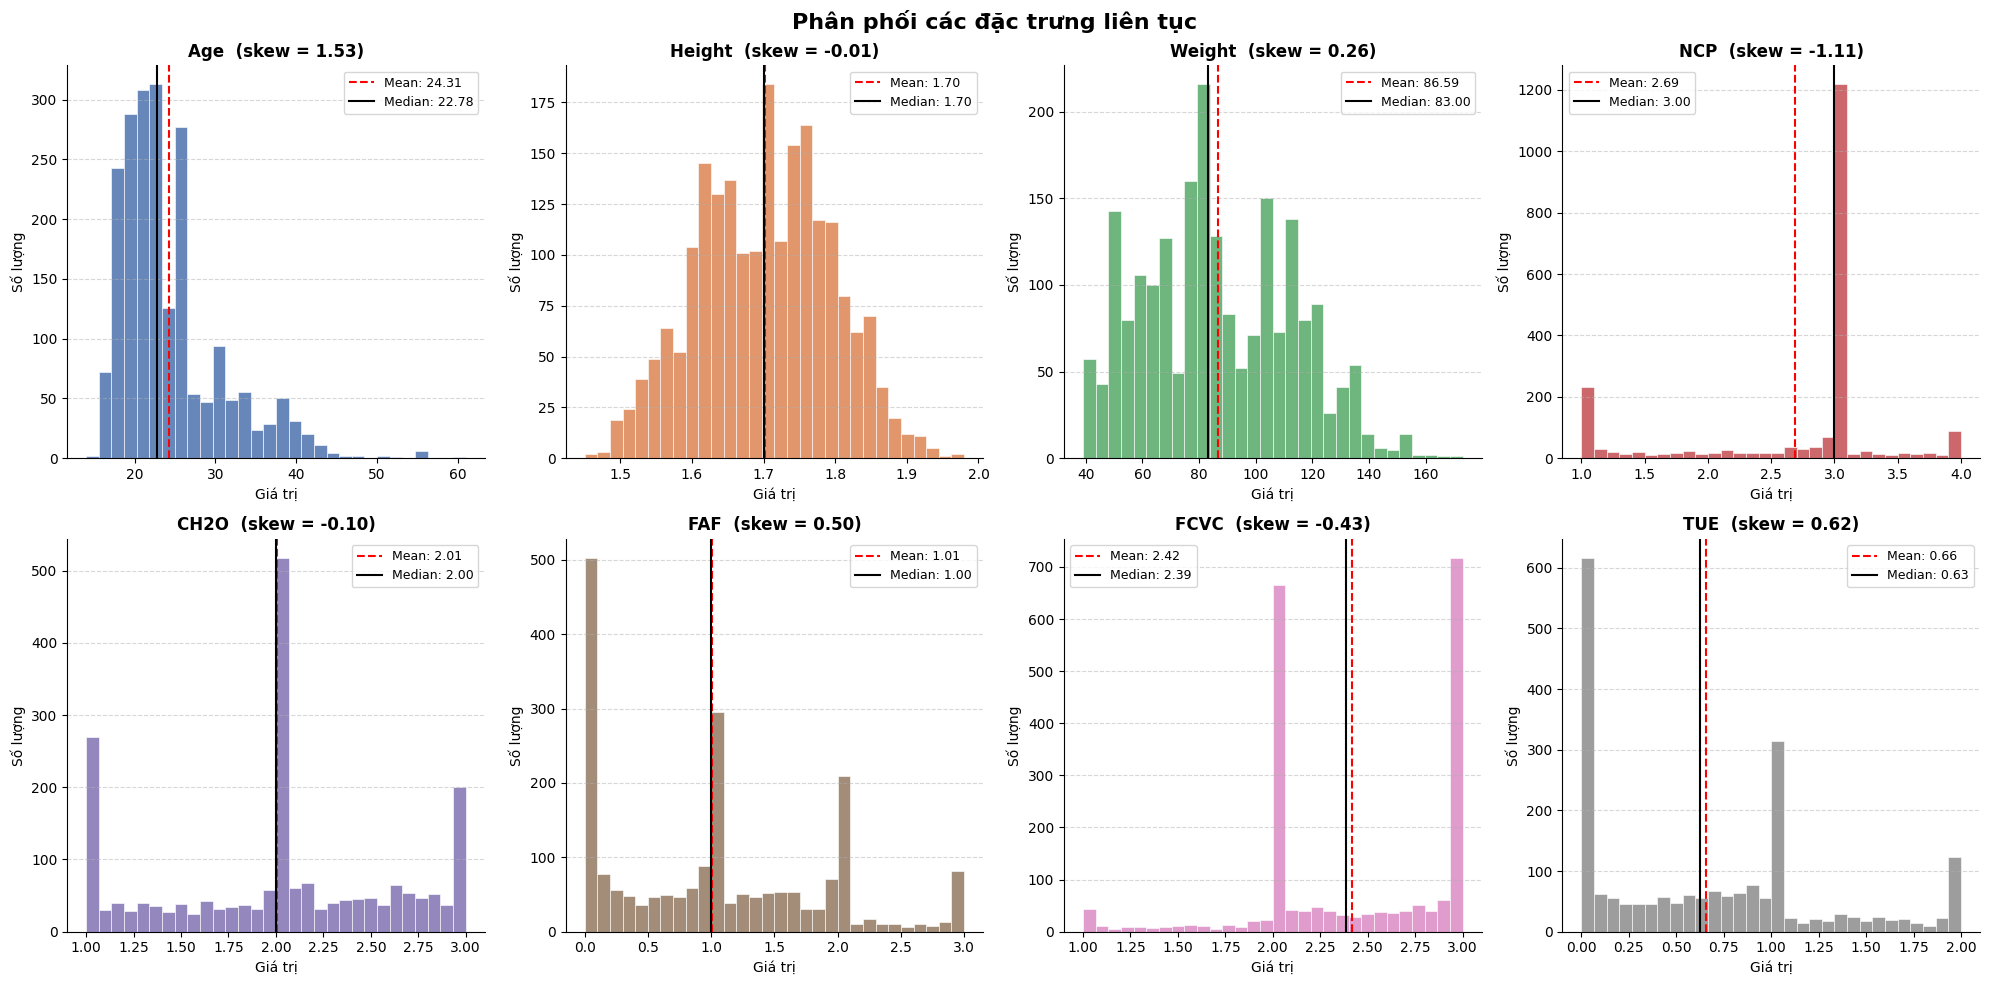

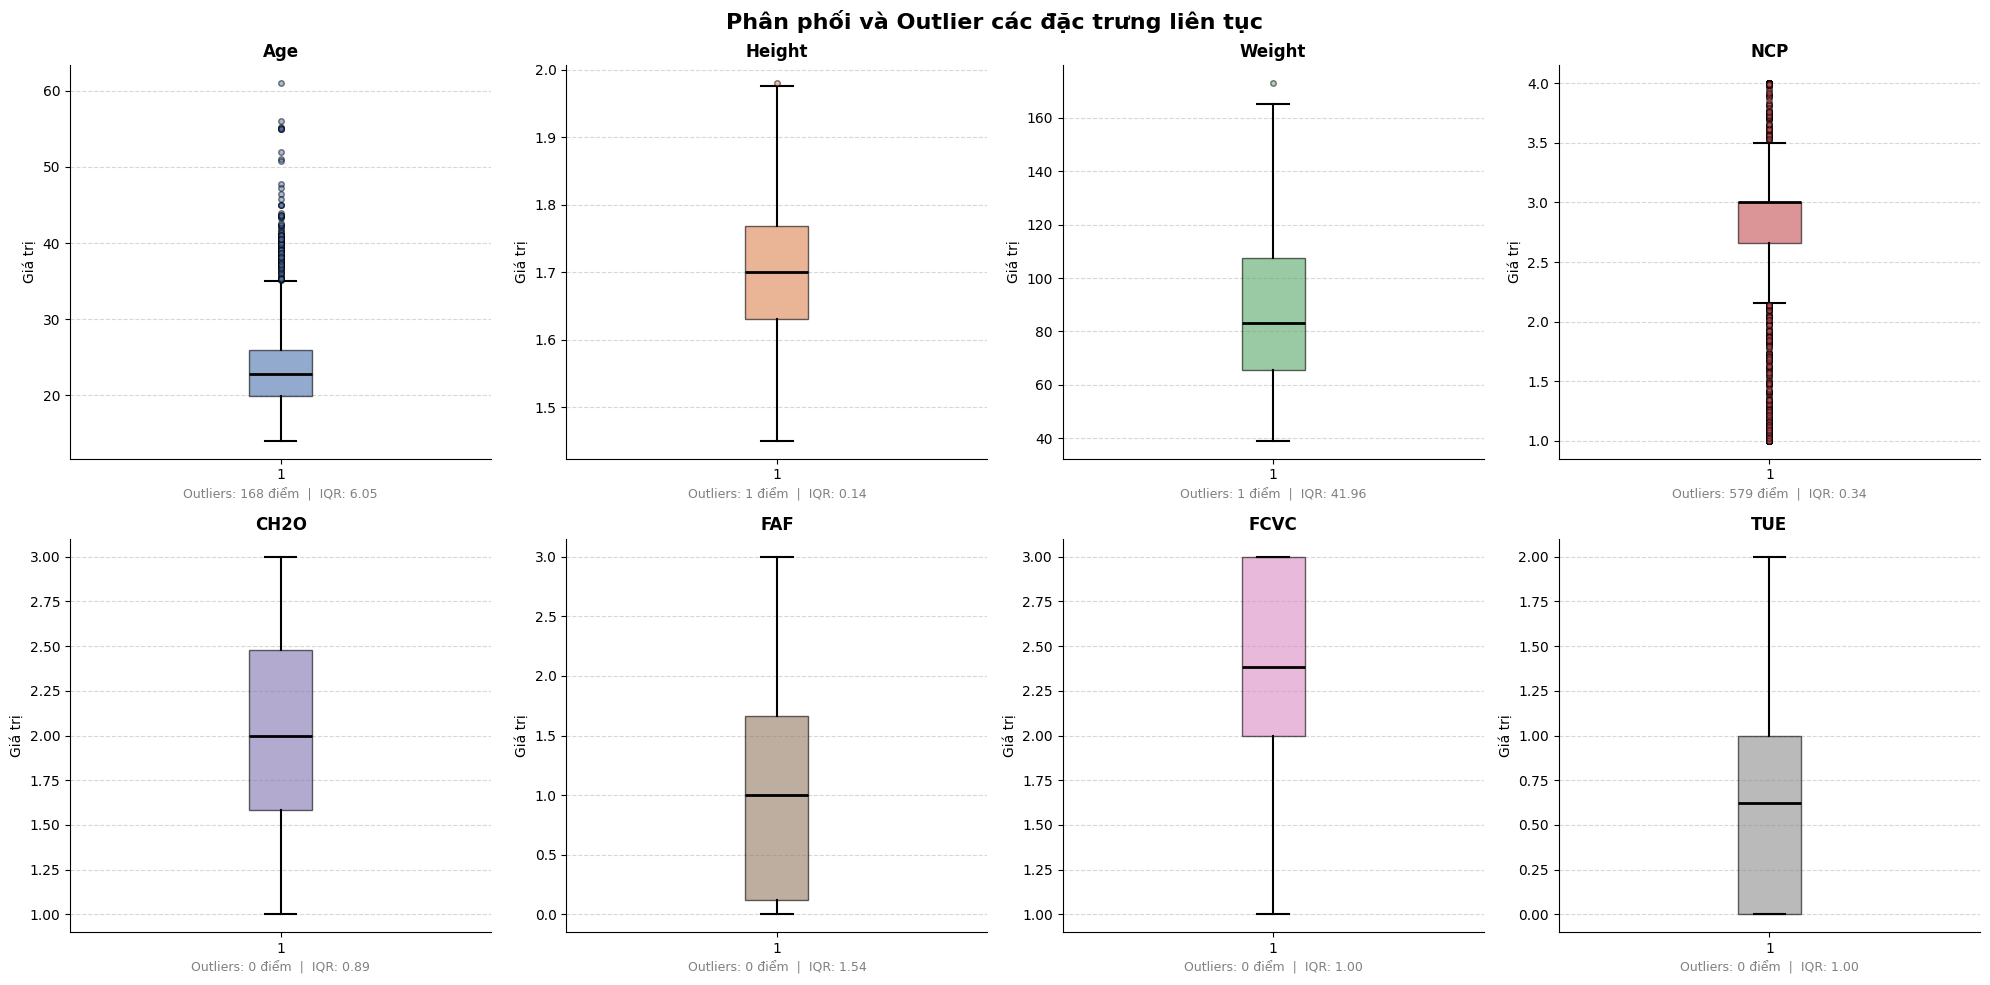

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_encoded = pd.read_csv("/content/obesity_encoded.csv")

cols   = ['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF','FCVC', 'TUE']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']

#histogram

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Phân phối các đặc trưng liên tục', fontsize=16, fontweight='bold')

for i, (col, color) in enumerate(zip(cols, colors)):
    ax = axes[i // 4][i % 4]
    skew_val = df_encoded[col].skew()

    ax.hist(df_encoded[col].dropna(), bins=30, color=color,
            edgecolor='white', linewidth=0.5, alpha=0.85)

    ax.axvline(df_encoded[col].mean(),   color='red',   linestyle='--', linewidth=1.5,
               label=f'Mean: {df_encoded[col].mean():.2f}')
    ax.axvline(df_encoded[col].median(), color='black', linestyle='-',  linewidth=1.5,
               label=f'Median: {df_encoded[col].median():.2f}')

    ax.set_title(f'{col}  (skew = {skew_val:.2f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Giá trị', fontsize=10)
    ax.set_ylabel('Số lượng', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('histogram.png', dpi=150, bbox_inches='tight')
plt.show()


# 2. BOXPLOT

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Phân phối và Outlier các đặc trưng liên tục', fontsize=16, fontweight='bold')

for i, (col, color) in enumerate(zip(cols, colors)):
    ax = axes[i // 4][i % 4]

    ax.boxplot(df_encoded[col].dropna(), patch_artist=True, vert=True,
               flierprops=dict(marker='o', markerfacecolor=color, markersize=4, alpha=0.5),
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.6),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5))

    q1  = df_encoded[col].quantile(0.25)
    q3  = df_encoded[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((df_encoded[col] < q1 - 1.5 * iqr) | (df_encoded[col] > q3 + 1.5 * iqr)).sum()

    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Giá trị', fontsize=10)
    ax.set_xlabel(f'Outliers: {n_outliers} điểm  |  IQR: {iqr:.2f}', fontsize=9, color='gray')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

1. Đánh giá độ lệch (skewness):
Kết quả quan sát từ biểu đồ cho thấy phân phối của một số đặc trưng không còn tính đối xứng. Cụ thể, biến Age có hệ số lệch skew = 1.53 và NCP có skew = 1.11, đều vượt ngưỡng 1 – mức thường được xem là biểu hiện của độ lệch lớn. Điều này cho thấy phân phối của hai biến này bị lệch phải rõ rệt, với phần đuôi kéo dài về phía các giá trị lớn. Ngược lại, các đặc trưng còn lại có hệ số lệch từ nhỏ đến trung bình, cho thấy phân phối tương đối cân đối và gần với phân phối chuẩn hơn.

2. Đánh giá giá trị ngoại lai (outliers):
Dựa trên biểu đồ, có thể nhận thấy hai đặc trưng Age và NCP xuất hiện nhiều giá trị ngoại lai. Các outlier này nằm xa so với phần lớn dữ liệu, góp phần làm gia tăng độ lệch của phân phối và có thể ảnh hưởng tiêu cực đến quá trình huấn luyện mô hình, đặc biệt đối với các thuật toán nhạy cảm với khoảng cách hoặc phân phối dữ liệu. Do đó, cần cân nhắc áp dụng các phương pháp xử lý phù hợp như biến đổi dữ liệu hoặc sử dụng kỹ thuật chuẩn hóa bền vững để giảm thiểu tác động của các giá trị ngoại lai.


Từ nhưng kết luận trên ta sẽ áp dụng:
- Phương pháp chuẩn hóa robust cho đặc trưng: Age, NCP
- Phương pháp chuẩn hóa standard cho đặc trưng: Height, Weight, CH2O, FAF, FCVC ,TUE,


Đoạn mã này sử dụng StandardScaler từ thư viện scikit-learn để chuẩn hóa dữ liệu. Việc chuẩn hóa là một bước rất quan trọng trong quy trình học máy, đặc biệt là đối với các mô hình nhạy cảm với sự khác biệt về đơn vị đo của các đặc trưng (như SVM, KNN, Logistic Regression,...).

StandardScaler: Đây là một công cụ trong scikit-learn dùng để chuẩn hóa các đặc trưng của dữ liệu bằng cách tạo ra dữ liệu có phân phối chuẩn (normal distribution) với:

*   Mean (trung bình) = 0.
*   Standard Deviation (độ lệch chuẩn) = 1.

**Công thức chuẩn hóa**

Xét lần lượt từng cột thuộc tính, với mỗi giá trị \( x \) thì ta chuẩn hóa thành $ x_{\text{scaled}} $ như sau:



$$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$$

Trong đó:
- \( x \) là giá trị của dữ liệu.
- \( N \) là số mẫu dữ liệu, ở đây cụ thể bằng 569.
- \( mu \) là giá trị trung bình của đặc trưng, được tính như sau:

$$
\mu = \frac{x_1 + x_2 + x_3 + \cdots + x_N}{N}
$$

- \( sigma \) là độ lệch chuẩn của đặc trưng, được tính như sau:

$$
\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}
$$

In [113]:
X_train = pd.read_csv("/content/X_train.csv")
X_test = pd.read_csv("/content/X_test.csv")
y_train = pd.read_csv("/content/y_train.csv")
y_test = pd.read_csv("/content/y_test.csv")

In [114]:
from sklearn.preprocessing import StandardScaler

standard_cols = ['Height', 'Weight', 'CH2O', 'FAF', 'FCVC', 'TUE',
                 'MTRANS', 'CALC', 'CAEC', 'Gender', 'FAVC', 'SCC',
                 'SMOKE', 'family_history_with_overweight']

standard_scaler = StandardScaler()

X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])


Đoạn mã này sử dụng RobustScaler từ thư viện scikit-learn để chuẩn hóa dữ liệu.

**RobustScaler** là một công cụ trong scikit-learn dùng để chuẩn hóa các đặc trưng
của dữ liệu. Khác với StandardScaler, RobustScaler sử dụng **median** và **IQR**
(Interquartile Range) thay vì mean và std, giúp **giảm ảnh hưởng của outliers**.

Công thức chuẩn hóa

Xét lần lượt từng cột thuộc tính, với mỗi giá trị $x$ thì ta chuẩn hóa thành
$x_{\text{scaled}}$ như sau:

$$
x_{\text{scaled}} = \frac{x - Q_2}{Q_3 - Q_1}
$$

Trong đó:
- $x$ là giá trị của dữ liệu.
- $Q_2$ là **median** (trung vị) của đặc trưng — giá trị ở vị trí 50%.
- $Q_1$ là **quartile thứ nhất** — giá trị ở vị trí 25%.
- $Q_3$ là **quartile thứ ba** — giá trị ở vị trí 75%.
- $IQR = Q_3 - Q_1$ là khoảng tứ phân vị, đo độ phân tán của 50% dữ liệu giữa.

In [115]:
from sklearn.preprocessing import RobustScaler

robust_cols = ['Age', 'NCP']

robust_scaler = RobustScaler()

X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

X_train.to_csv("X_train_scaled.csv", index=False)
X_test.to_csv("X_test_scaled.csv", index=False)

Dữ liệu sau khi chuẩn hóa

In [116]:
X_train.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS
0,0.523702,-1.018450,-0.803003,0.719123,-0.532293,0.349772,1.087913,0.0,-0.212823,-0.155794,-0.850559,0.464368,-1.081814,0.026802,0.294954,-0.478175
1,0.526680,-1.018450,-0.496412,0.969880,-0.532293,0.349772,1.087913,0.0,-0.212823,-0.155794,1.258912,0.464368,-1.198990,-0.842365,0.294954,-0.478175
2,-0.805134,0.981884,0.512332,-0.015543,-0.532293,0.349772,0.914154,0.0,-0.212823,-0.155794,1.204814,0.464368,0.258885,-1.009196,0.294954,-0.478175
3,-0.139227,-1.018450,-0.026553,-0.800929,-0.532293,-2.859006,1.087913,0.0,4.698737,-0.155794,-0.003599,0.464368,1.191307,0.583831,-4.083413,-0.478175
4,0.102430,0.981884,-0.346817,-0.453961,-0.532293,0.349772,-0.781717,0.0,-0.212823,-0.155794,-0.003599,0.464368,-1.044621,2.212137,0.294954,-0.478175


## 2.3 Phân tích thành phần chính (PCA)

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score


In [118]:
X_train_scaled = pd.read_csv("/content/X_train_scaled.csv")
X_test_scaled = pd.read_csv("/content/X_test_scaled.csv")

 Thực hiện giảm chiều bằng PCA

pca = PCA()
*   PCA(): Đây là cách khởi tạo một đối tượng của lớp PCA từ thư viện scikit-learn.
*   Khi khởi tạo PCA mà không truyền thêm tham số, PCA sẽ giữ lại tất cả các thành phần chính của dữ liệu.

fit_transform(): Đây là một phương thức kết hợp hai bước trong quá trình PCA:


*   fit(): Phương thức này học các thành phần chính từ bộ dữ liệu huấn luyện (X_train_scaled). Nó sẽ tính toán ma trận hiệp phương sai của dữ liệu và tìm các thành phần chính.
*   transform(): Sau khi đã "học" xong các thành phần chính, phương thức transform() sẽ chiếu dữ liệu gốc vào không gian mới được tạo ra bởi các thành phần chính.


In [119]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

###Phân tích phương sai giải thích

Đây là thuộc tính của đối tượng PCA sau khi đã thực hiện fit() trên dữ liệu. Nó trả về tỷ lệ phương sai giải thích của mỗi thành phần chính.
Phương sai giải thích cho biết mức độ quan trọng của mỗi thành phần chính trong việc giải thích sự biến thiên trong dữ liệu.
Kết quả explained_variance là một mảng chứa tỷ lệ phương sai giải thích của từng thành phần chính.

np.cumsum(): Đây là hàm trong thư viện NumPy tính tổng dồn của một mảng. Cộng dồn các giá trị của explained_variance để tính tổng phương sai giải thích của tất cả các thành phần chính đến một thành phần chính cụ thể.

cumulative_variance: Kết quả là một mảng chứa tổng phương sai giải thích tích lũy của các thành phần chính.


In [120]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

 Vẽ biểu đồ phương sai giải thích PCA.
Biểu đồ này sẽ giúp bạn hiểu được mức độ đóng góp của các thành phần chính trong PCA vào phương sai tổng thể, với một ngưỡng được chỉ ra để xác định số lượng thành phần chính cần thiết để giải thích ít nhất 95% phương sai của dữ liệu.

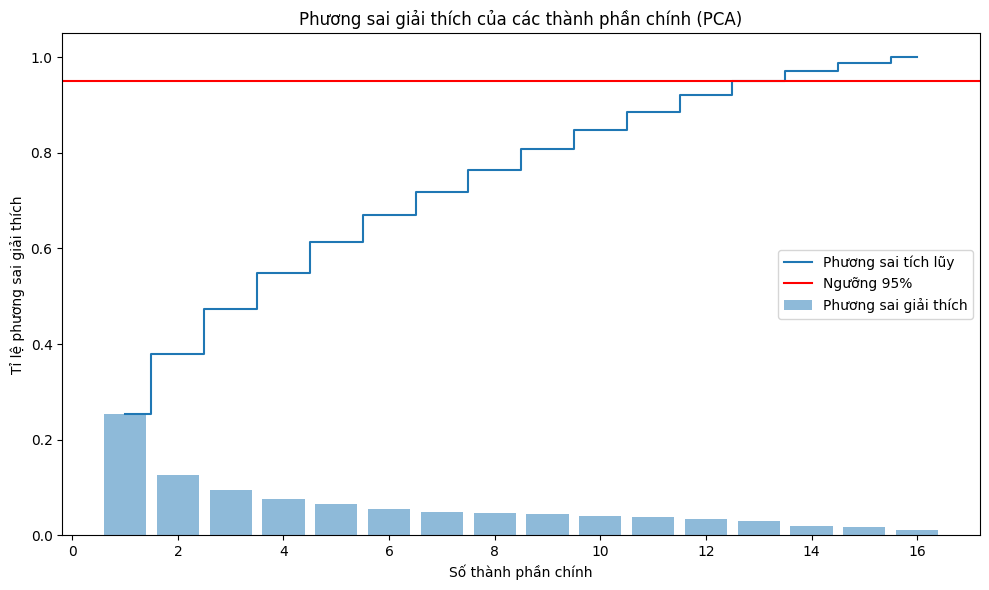

In [121]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center',
        label='Phương sai giải thích')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
         label='Phương sai tích lũy')
plt.axhline(y=0.95, color='r', linestyle='-', label='Ngưỡng 95%')
plt.xlabel('Số thành phần chính')
plt.ylabel('Tỉ lệ phương sai giải thích')
plt.title('Phương sai giải thích của các thành phần chính (PCA)')
plt.legend(loc='best')
plt.tight_layout()

Từ kết quả trên cho thấy cần ít nhất 13 thành phần chính để tổng phương sai giữ lại là trên 95%

In [122]:
y_test = pd.read_csv("/content/y_test.csv")
y_train = pd.read_csv("/content/y_train.csv")
pca = PCA(n_components=13)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_columns = [f'PC{i+1}' for i in range(13)]

df_train_pca = pd.DataFrame(X_train_pca, columns=pca_columns)
df_train_pca['NObeyesdad'] = y_train.values.ravel()

df_test_pca = pd.DataFrame(X_test_pca, columns=pca_columns)
df_test_pca['NObeyesdad'] = y_test.values.ravel()

df_train_pca.to_csv("X_train_pca.csv", index=False)
df_test_pca.to_csv("X_test_pca.csv", index=False)

TRỰC QUAN HÓA DỮ LIỆU PCA

Trực quan hóa dữ liệu sau khi áp dụng PCA bằng cách vẽ biểu đồ phân tán cho hai thành phần chính đầu tiên. Việc này giúp hình dung sự phân bố và mối quan hệ giữa các mẫu dữ liệu trong không gian giảm chiều.

Màu sắc của các điểm dựa trên nhãn lớp (y_train) giúp ta thấy rõ sự phân tách giữa các nhóm dữ liệu khác nhau, từ đó dễ dàng đánh giá liệu dữ liệu có thể được phân loại rõ ràng hay không trong không gian giảm chiều.

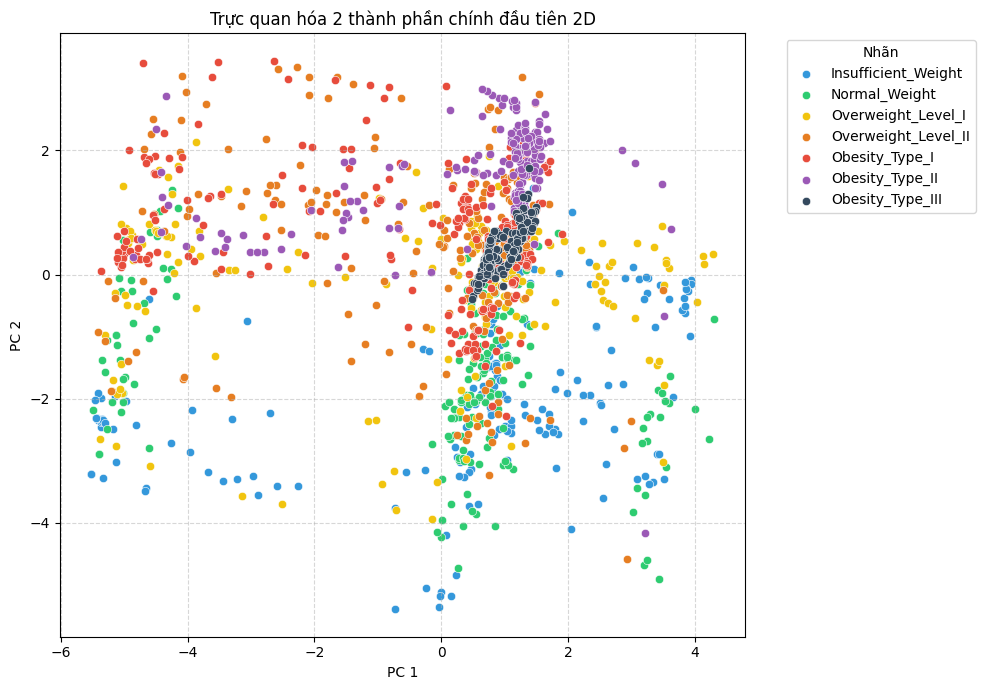

In [123]:
import pandas as pd
import matplotlib.pyplot as plt

X_pca = pd.read_csv("X_train_pca.csv")
X_pca = X_pca.drop(X_pca.columns[13], axis=1)
y_train = pd.read_csv("y_train.csv")

label_map = {
    0: "Insufficient_Weight",
    1: "Normal_Weight",
    2: "Overweight_Level_I",
    3: "Overweight_Level_II",
    4: "Obesity_Type_I",
    5: "Obesity_Type_II",
    6: "Obesity_Type_III"
}

y_train['NObeyesdad'] = y_train['NObeyesdad'].map(label_map)

df = pd.concat([X_pca.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)

label_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

colors = ["#3498db", "#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#9b59b6", "#34495e"]

plt.figure(figsize=(10, 7))

for label, color in zip(label_order, colors):
    subset = df[df["NObeyesdad"] == label]
    if not subset.empty:
        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=label,
            color=color,
            alpha=1,
            edgecolors='w',
            linewidth=0.4
        )

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Trực quan hóa 2 thành phần chính đầu tiên 2D")
plt.legend(title="Nhãn", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Tiếp tục trực quan hóa với 4 thành phần chính đầu tiên

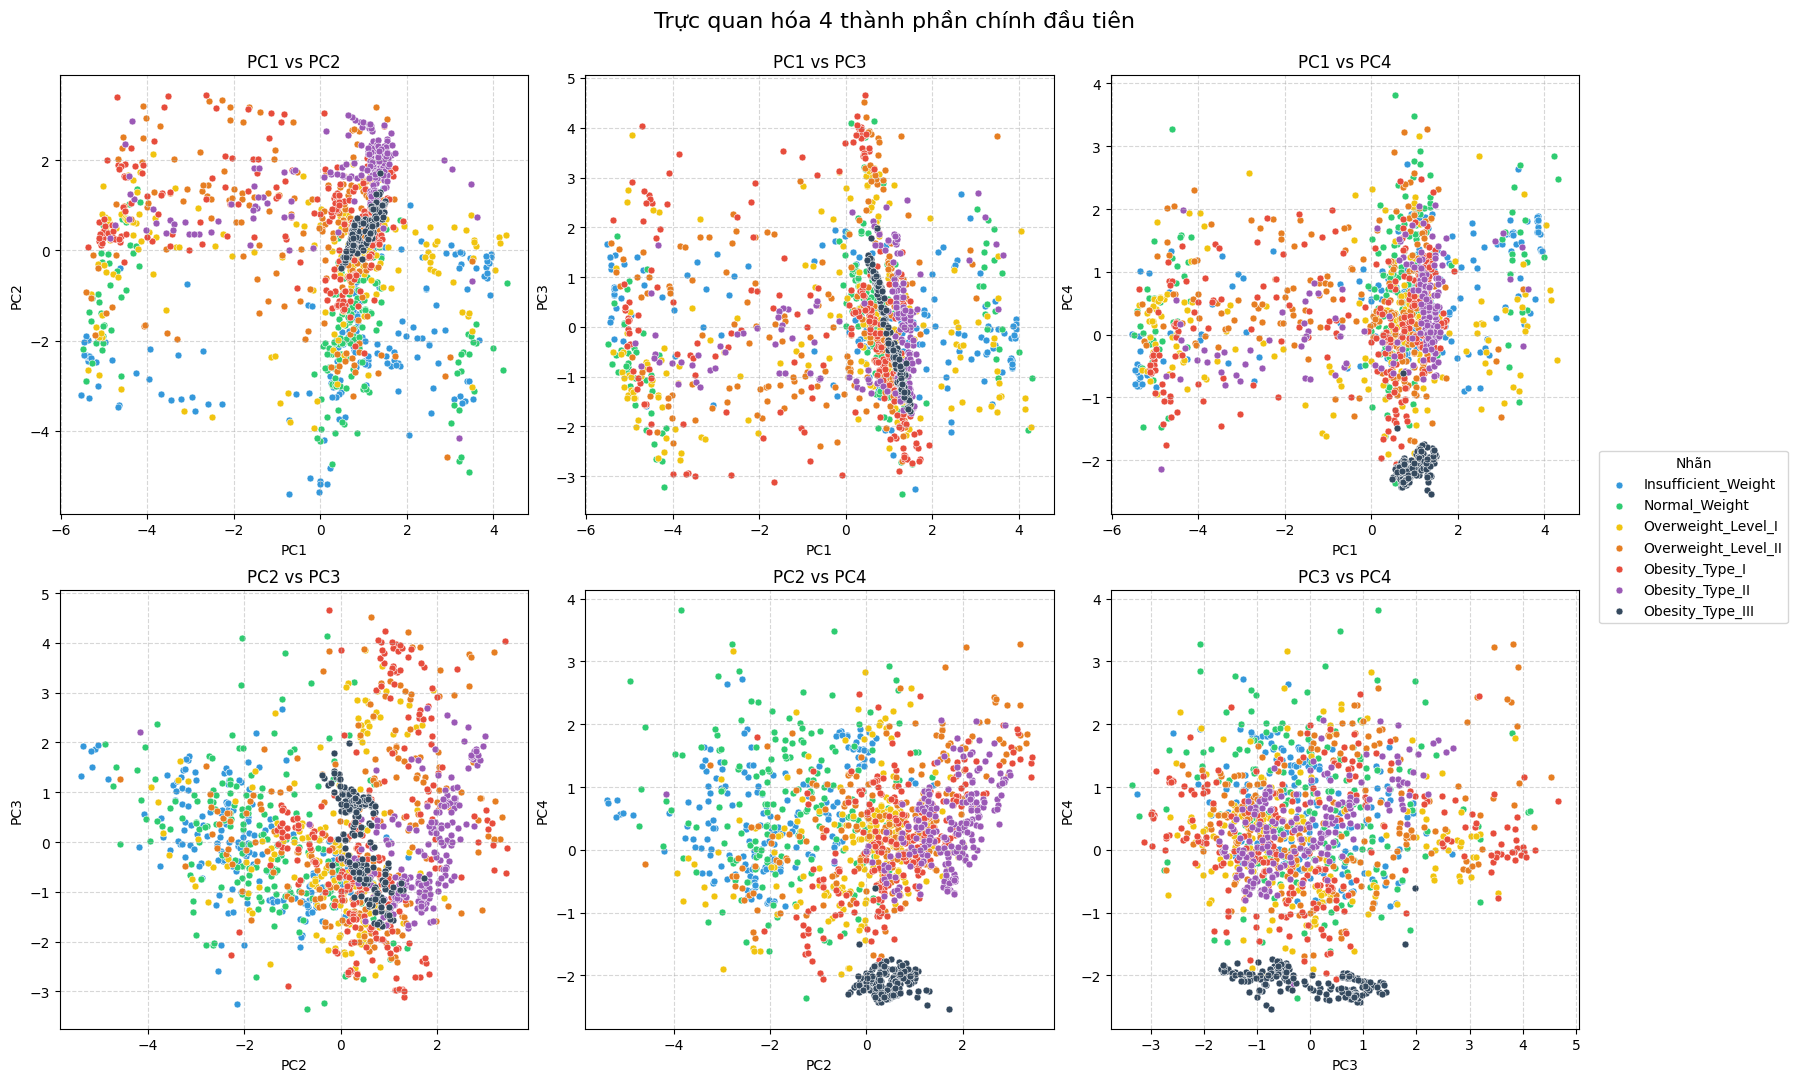

In [124]:
import matplotlib.pyplot as plt

pc_pairs = [
    ('PC1', 'PC2'), ('PC1', 'PC3'), ('PC1', 'PC4'),
    ('PC2', 'PC3'), ('PC2', 'PC4'), ('PC3', 'PC4')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (pc_x, pc_y) in enumerate(pc_pairs):
    ax = axes[i]
    for label, color in zip(label_order, colors):
        subset = df[df["NObeyesdad"] == label]
        if not subset.empty:
            ax.scatter(
                subset[pc_x],
                subset[pc_y],
                label=label,
                color=color,
                alpha=1,
                edgecolors='w',
                linewidth=0.4,
                s=25
            )
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.set_title(f"{pc_x} vs {pc_y}")
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Nhãn", loc='center right', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.subplots_adjust(right=0.88, top=0.92)
plt.suptitle("Trực quan hóa 4 thành phần chính đầu tiên", fontsize=16)

plt.show()

ĐÁNH GIÁ KẾT QUẢ SAU GIẢM CHIỀU

Kết quả phân tích cho thấy chỉ phân tách tốt một số lớp nhất định, trong khi phần lớn các lớp còn lại vẫn bị chồng lấp đáng kể.

Về mặt tích cực, lớp Obesity_Type_III (xám) được tách biệt khá rõ ràng trong hầu hết các cặp thành phần chính, đặc biệt nổi bật ở các biểu đồ PC1 vs PC4 và PC3 vs PC4. Điều này cho thấy nhóm dữ liệu này có đặc trưng rất riêng biệt và dễ phân biệt so với các lớp còn lại. Đồng thời, PC1 cũng đóng vai trò quan trọng trong việc phân tách, khi quan sát trên mặt phẳng PC1 vs PC2 có thể thấy Obesity_Type_III tập trung về một phía rõ rệt, thể hiện khả năng đóng góp của thành phần này trong việc tách nhóm dữ liệu.

Tuy nhiên, hạn chế lớn nhất nằm ở các lớp còn lại gồm Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I và Obesity_Type_II. Các lớp này chồng lấp gần như hoàn toàn trên tất cả các cặp thành phần chính, cho thấy không tồn tại một không gian tuyến tính nào trong các PC có thể phân tách tốt giữa chúng. Điều này phản ánh mức độ tương đồng cao giữa các nhóm trung gian, khiến việc phân biệt trở nên khó khăn.

Bên cạnh đó, các thành phần PC2, PC3 và PC4 hầu như không đóng góp đáng kể vào việc phân tách lớp. Quan sát cho thấy dữ liệu phân bố trộn lẫn ngẫu nhiên theo nhiều hướng, không hình thành ranh giới rõ ràng giữa các lớp. Ngoài ra, không xuất hiện xu hướng phân bố dạng gradient theo mức độ béo phì như kỳ vọng ban đầu, cho thấy cấu trúc dữ liệu trong không gian giảm chiều chưa phản ánh rõ tính thứ bậc giữa các nhóm.

Phân tích mối quan hệ giữa các thành phần chính và các đặc trưng gốc

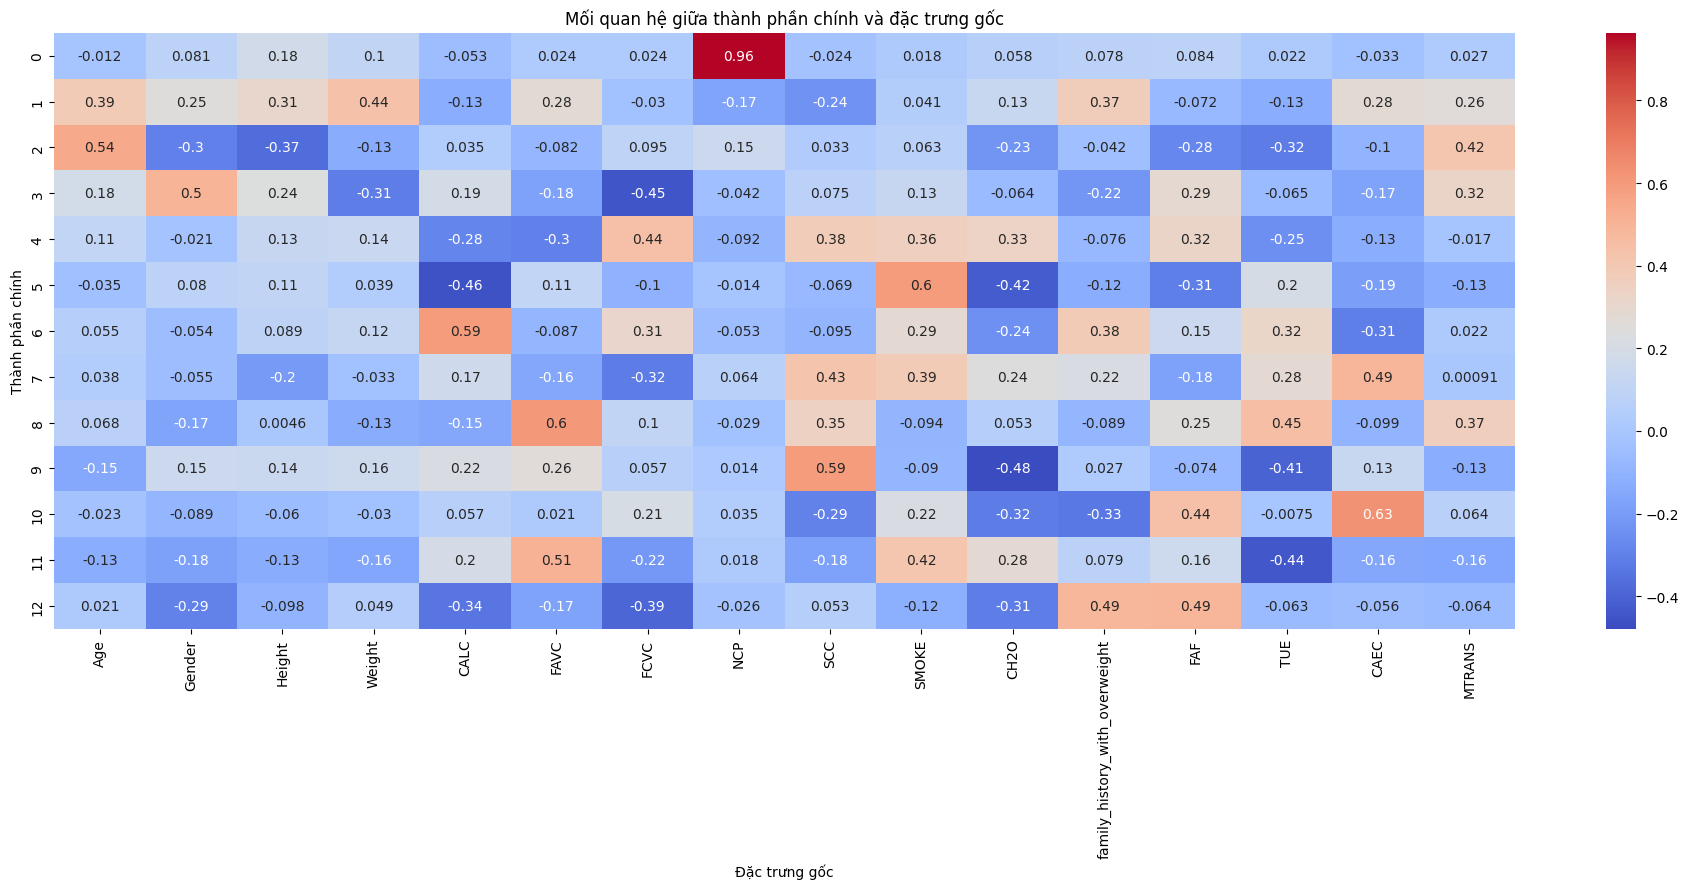

In [125]:
X_scaled = pd.read_csv('/content/X_train_scaled.csv')
pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

pca_components = pd.DataFrame(
    pca.components_,
    columns=X_scaled.columns
)

plt.figure(figsize=(19, 9))
sns.heatmap(pca_components.iloc[:n_components_95], annot=True, cmap='coolwarm')
plt.xlabel('Đặc trưng gốc')
plt.ylabel('Thành phần chính')
plt.title('Mối quan hệ giữa thành phần chính và đặc trưng gốc')
plt.tight_layout()

## 2.4 Phân tích phân biệt tuyến tính (LDA)

### Thực hiện LDA
Đoạn mã này thực hiện giảm chiều dữ liệu bằng phương pháp Linear Discriminant Analysis (LDA). Mục đích của LDA là giảm số lượng đặc trưng (features) trong dữ liệu trong khi vẫn giữ được khả năng phân biệt giữa các lớp dữ liệu.

1.   Xác định số lớp trong tập huấn luyện: np.unique(y_train) trả về các giá trị duy nhất trong y_train, và len() trả về số lượng các lớp khác nhau.
2.   Xác định số thành phần cần giữ lại: Số lượng thành phần (components) trong LDA bị giới hạn bởi số lớp - 1 và số lượng đặc trưng trong dữ liệu. Nếu số lượng lớp ít hơn số đặc trưng, số thành phần được chọn sẽ là số lớp - 1. Ngược lại, nếu số lớp nhiều hơn số đặc trưng, số thành phần chỉ có thể tối đa bằng số đặc trưng.
3.   Khởi tạo mô hình LDA: Dùng thư viện sklearn để tạo một mô hình LDA, và chỉ định số thành phần (số chiều giảm xuống).
4.   Áp dụng phương pháp LDA vào tập huấn luyện.
5.   Giảm chiều dữ liệu kiểm tra



In [126]:
X_train_scaled = pd.read_csv("/content/X_train_scaled.csv")
X_test_scaled = pd.read_csv("/content/X_test_scaled.csv")
n_classes = len(np.unique(y_train))
n_components_lda = min(n_classes - 1, X_train_scaled.shape[1])
lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
X_lda = lda.fit_transform(X_train_scaled, y_train)
print("Số components:", lda.scalings_.shape[1])
print("Explained variance ratio:", lda.explained_variance_ratio_)
print("Cumulative variance:", lda.explained_variance_ratio_.cumsum())

Số components: 6
Explained variance ratio: [0.93100072 0.04801958 0.00965614 0.00527369 0.00330736 0.00274251]
Cumulative variance: [0.93100072 0.9790203  0.98867644 0.99395013 0.99725749 1.        ]


Khác với PCA, số thành phần chính thường được chọn dựa trên lượng phương sai dữ liệu được giữ lại (ví dụ 95%). Tuy nhiên, đối với Linear Discriminant Analysis, mục tiêu chính không phải là giữ lại phương sai mà là tối đa khả năng phân tách giữa các lớp dữ liệu.

Vì vậy, số chiều LD phù hợp không cố định mà phụ thuộc vào mô hình học máy được sử dụng phía sau. Một số mô hình có thể hoạt động tốt với ít thành phần LD do dữ liệu đã được phân tách rõ ràng, trong khi các mô hình khác cần nhiều thành phần hơn để giữ đủ thông tin phân biệt.

Do đó, số lượng thành phần LDA thường được lựa chọn bằng cách thử nhiều giá trị LD khác nhau và đánh giá hiệu năng mô hình thông qua Cross-Validation với các chỉ số như Accuracy hoặc F1-score. Giá trị LD cho kết quả đánh giá tốt nhất sẽ được chọn làm số chiều tối ưu.




TRỰC QUAN HÓA DỮ LIỆU LDA

Trong phần trực quan hóa dữ liệu, nhóm lựa chọn 2 thành phần LD nhằm thuận tiện cho việc phân tích và quan sát sự phân tách giữa các lớp trên tập train. Tuy nhiên, đối với các mô hình được sử dụng ở các bước sau như Support Vector Machine hay Logistic-Softmax, số lượng thành phần LD sẽ được lựa chọn riêng sao cho tối ưu hiệu năng của từng mô hình

In [127]:
y_test = pd.read_csv("/content/y_test.csv")
y_train = pd.read_csv("/content/y_train.csv")

n_classes = len(np.unique(y_train))
max_components = min(n_classes - 1, X_train_scaled.shape[1])

lda = LinearDiscriminantAnalysis(n_components=max_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train.values.ravel())
X_test_lda = lda.transform(X_test_scaled)

# Xuất file với từng số LD
for n in range(1, max_components + 1):
    lda_columns = [f'LD{i+1}' for i in range(n)]

    df_train = pd.DataFrame(X_train_lda[:, :n], columns=lda_columns)
    df_train['NObeyesdad'] = y_train.values.ravel()
    df_train.to_csv(f'X_train_lda_{n}.csv', index=False)

    df_test = pd.DataFrame(X_test_lda[:, :n], columns=lda_columns)
    df_test['NObeyesdad'] = y_test.values.ravel()
    df_test.to_csv(f'X_test_lda_{n}.csv', index=False)

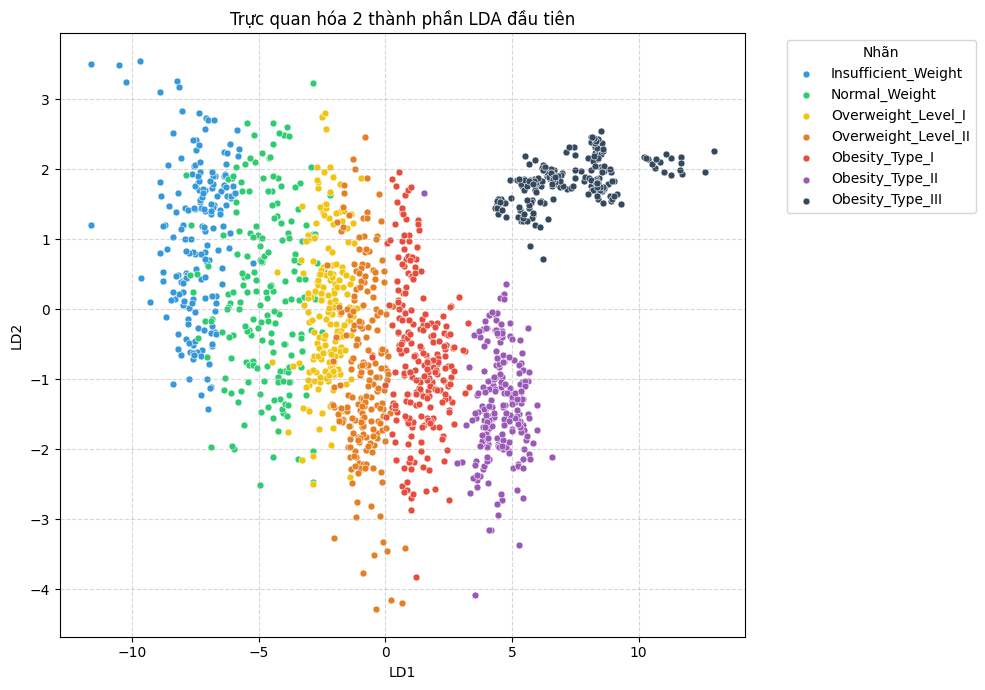

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

df_lda = pd.read_csv("/content/X_train_lda_2.csv")

label_map = {
    0: "Insufficient_Weight",
    1: "Normal_Weight",
    2: "Overweight_Level_I",
    3: "Overweight_Level_II",
    4: "Obesity_Type_I",
    5: "Obesity_Type_II",
    6: "Obesity_Type_III"
}

df_lda['NObeyesdad'] = df_lda['NObeyesdad'].map(label_map)

label_order = list(label_map.values())
colors = ["#3498db", "#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#9b59b6", "#34495e"]

plt.figure(figsize=(10, 7))

for label, color in zip(label_order, colors):
    subset = df_lda[df_lda["NObeyesdad"] == label]
    if not subset.empty:
        plt.scatter(
            subset["LD1"],
            subset["LD2"],
            label=label,
            color=color,
            alpha=1,
            edgecolors='w',
            linewidth=0.4,
            s=25
        )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Trực quan hóa 2 thành phần LDA đầu tiên")
plt.legend(title="Nhãn", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Đánh giá kết quả sau giảm chiều

Linear Discriminant Analysis cho thấy khả năng phân tách các lớp dữ liệu khá rõ rệt, đặc biệt ở thành phần LD1.

Cụ thể, lớp Obesity_Type_III (xám đậm) được tách biệt hoàn toàn ở khu vực góc phải phía trên, cho thấy đây là nhóm có đặc trưng rất rõ ràng và LDA phân biệt tốt nhất trong toàn bộ tập dữ liệu. Đồng thời, LD1 đóng vai trò quan trọng trong việc phân tách chính giữa các lớp: khi quan sát theo trục ngang, có thể thấy xu hướng rõ ràng từ các nhóm có mức độ béo phì thấp như Insufficient_Weight và Normal_Weight ở phía bên trái, dần chuyển sang các nhóm có mức độ béo phì cao hơn ở phía bên phải. Điều này phản ánh đúng xu hướng y khoa thực tế về mức độ tăng dần của béo phì.

Tuy nhiên, vẫn tồn tại một số hạn chế trong khả năng phân tách của mô hình. Các lớp Insufficient_Weight (xanh dương), Normal_Weight (xanh lá) và Overweight_Level_I (vàng) bị chồng lấn đáng kể tại khu vực trung tâm bên trái, cho thấy đây là những nhóm khó phân biệt nhất và là nguồn gây nhiễu chính trong không gian LD, phù hợp với giá trị Silhouette Score khoảng 0.41. Bên cạnh đó, hai lớp Obesity_Type_I (đỏ) và Obesity_Type_II (tím) cũng có hiện tượng chồng lấn nhất định, làm giảm độ tách biệt giữa các nhóm trung gian.

Ngoài ra, thành phần LD2 đóng góp khá hạn chế trong việc phân tách dữ liệu. Các lớp phân bố dọc theo trục này nhưng không hình thành ranh giới rõ ràng, cho thấy LD2 chủ yếu mang tính bổ trợ và không phải trục phân biệt chính giữa các lớp.

##2.5 So sánh PCA với LDA và đánh giá kết quả giảm chiều

Từ 2 kết quả trên cho thấy LDA vượt trội hơn PCA trong việc giảm chiều cho bộ dữ liệu này. Trong khi PCA chỉ tối ưu hóa phương sai tổng thể mà không quan tâm đến nhãn lớp, dẫn đến các class bị chồng lấp gần như hoàn toàn trong không gian chiếu, LDA tập trung tối đa hóa khả năng phân tách giữa các lớp, tạo ra không gian chiếu có cấu trúc rõ ràng hơn.



# **PHẦN III. CÁC MÔ HÌNH PHÂN LOẠI**

##Đánh giá overfit và hiệu chỉnh (regularization)

K-fold Cross-Validation là phương pháp đánh giá mô hình phổ biến trong machine learning nhằm kiểm tra khả năng tổng quát hóa của mô hình trên dữ liệu chưa thấy trước. Phương pháp này hoạt động bằng cách chia tập dữ liệu thành K phần bằng nhau (gọi là folds), trong đó mỗi lần huấn luyện sẽ sử dụng K−1 folds làm tập train và 1 fold còn lại làm tập validation để đánh giá mô hình. Quá trình này được lặp lại K lần sao cho mỗi fold đều được sử dụng một lần làm validation, sau đó kết quả đánh giá cuối cùng được tính bằng trung bình của tất cả các lần chạy. K-fold Cross-Validation giúp giảm sự phụ thuộc vào một cách chia dữ liệu duy nhất, từ đó cho kết quả đánh giá ổn định và đáng tin cậy hơn. Trong quá trình thực hiện.

**Cách đánh giá overfit qua K-fold Cross-Validation**

Sau khi chạy K-fold, mỗi lần lặp sẽ trả về điểm số trên tập train và tập validation. Từ đó, ta tính trung bình qua K lần để có hai chỉ số chính:

- **CV Train Score**: trung bình độ chính xác trên tập huấn luyện qua K folds.
- **CV Validation Score**: trung bình độ chính xác trên tập validation qua K folds.

Chênh lệch giữa hai chỉ số này — gọi là **Gap** — là thước đo trực tiếp mức độ overfit:

In [129]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

X_train_scaled = pd.read_csv("/content/X_train_scaled.csv")
X_train_PCA    = pd.read_csv("/content/X_train_pca.csv")
X_train_LDA    = pd.read_csv("/content/X_train_lda_6.csv")
X_test_scaled  = pd.read_csv("/content/X_test_scaled.csv")
X_test_PCA     = pd.read_csv("/content/X_test_pca.csv")
X_test_LDA     = pd.read_csv("/content/X_test_lda_6.csv")

y_train = X_train_PCA.pop("NObeyesdad")
y_test  = X_test_PCA.pop("NObeyesdad")
X_train_LDA.pop("NObeyesdad")
X_test_LDA.pop("NObeyesdad")

models = {
    "Softmax": LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42),
    "SVM"    : SVC(kernel="linear", C=1, class_weight="balanced", random_state=42),
    "KNN"    : KNeighborsClassifier(n_neighbors=11, metric="manhattan", weights="uniform"),
}

datasets = {
    "Gốc": (X_train_scaled, X_test_scaled),
    "PCA": (X_train_PCA,    X_test_PCA),
    "LDA": (X_train_LDA,    X_test_LDA),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
records = []

for data_name, (X_train, X_test) in datasets.items():
    for model_name, model in models.items():

        cv_results = cross_validate(
            model, X_train, y_train,
            cv=skf,
            scoring=["accuracy", "f1_macro"],
            return_train_score=True,
        )

        cv_train_acc = cv_results["train_accuracy"].mean()
        cv_val_acc   = cv_results["test_accuracy"].mean()
        cv_train_f1  = cv_results["train_f1_macro"].mean()
        cv_val_f1    = cv_results["test_f1_macro"].mean()

        model.fit(X_train, y_train)
        y_pred   = model.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)
        test_f1  = f1_score(y_test, y_pred, average="macro")

        gap_acc = cv_train_acc - cv_val_acc
        gap_f1  = cv_train_f1  - cv_val_f1

        if gap_acc > 0.05:
            status = "  Overfit"
        elif cv_val_acc - test_acc > 0.05:
            status = "  Val > Test (kiểm tra leakage)"
        else:
            status = "  Ổn định"

        records.append({
            "Dataset"         : data_name,
            "Model"           : model_name,
            "CV Train Acc"    : round(cv_train_acc, 4),
            "CV Val Acc"      : round(cv_val_acc,   4),
            "Test Acc"        : round(test_acc,     4),
            "Gap Acc (Tr-Val)": round(gap_acc,      4),
            "CV Train F1"     : round(cv_train_f1,  4),
            "CV Val F1"       : round(cv_val_f1,    4),
            "Test F1"         : round(test_f1,      4),
            "Gap F1 (Tr-Val)" : round(gap_f1,       4),
            "Trạng thái"      : status,
        })

df_results = pd.DataFrame(records)

print("\n" + "="*80)
print("KẾT QUẢ ĐÁNH GIÁ OVERFIT QUA K-FOLD CROSS-VALIDATION (k=5)")
print("="*80)

for data_name in datasets.keys():
    print(f"\n Dataset: {data_name}")
    print("-" * 70)
    sub = df_results[df_results["Dataset"] == data_name][
        ["Model", "CV Train Acc", "CV Val Acc", "Test Acc",
         "Gap Acc (Tr-Val)", "CV Val F1", "Test F1", "Trạng thái"]
    ]
    print(sub.to_string(index=False))


KẾT QUẢ ĐÁNH GIÁ OVERFIT QUA K-FOLD CROSS-VALIDATION (k=5)

 Dataset: Gốc
----------------------------------------------------------------------
  Model  CV Train Acc  CV Val Acc  Test Acc  Gap Acc (Tr-Val)  CV Val F1  Test F1 Trạng thái
Softmax        0.8885      0.8646    0.8644            0.0239     0.8603   0.8579    Ổn định
    SVM        0.9584      0.9411    0.9527            0.0173     0.9390   0.9512    Ổn định
    KNN        0.8546      0.8199    0.8297            0.0347     0.8092   0.8197    Ổn định

 Dataset: PCA
----------------------------------------------------------------------
  Model  CV Train Acc  CV Val Acc  Test Acc  Gap Acc (Tr-Val)  CV Val F1  Test F1 Trạng thái
Softmax        0.6794      0.6533    0.6688            0.0261     0.6324   0.6548    Ổn định
    SVM        0.7244      0.6838    0.6972            0.0406     0.6650   0.6840    Ổn định
    KNN        0.7818      0.7359    0.7350            0.0459     0.7164   0.7180    Ổn định

 Dataset: LDA
---------

Có thể thấy sau khi hiệu chỉnh tham số, cả ba mô hình KNN, SVM và Softmax đều cho thấy chênh lệch Gap ≤ 0.05 trên hầu hết các tập dữ liệu, cho thấy mô hình không còn bị overfit và có khả năng tổng quát hóa tốt. Cụ thể, SVM được chuyển từ kernel RBF sang kernel tuyến tính để giảm độ phức tạp của biên phân loại, KNN được đổi từ trọng số distance sang uniform kết hợp tăng số láng giềng lên k=11 để ổn định hóa dự đoán, còn Softmax vốn đã ổn định nên được giữ nguyên tham số. Dựa trên kết quả đánh giá này, nhóm tiến hành huấn luyện chính thức trên toàn bộ tập train với các tham số đã hiệu chỉnh và đánh giá hiệu năng cuối cùng trên tập test.

##Softmax Regression

In [130]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, f1_score,accuracy_score,precision_score, recall_score
import joblib

import warnings
warnings.filterwarnings('ignore')

In [131]:
class_names = [
    'Insufficient\nWeight',
    'Normal\nWeight',
    'Overweight\nLevel I',
    'Overweight\nLevel II',
    'Obesity\nType I',
    'Obesity\nType II',
    'Obesity\nType III',
]

custom_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#e377c2', '#8c564b', '#7f7f7f',
]

TARGET = "NObeyesdad"

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{title.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred))
    plot_confusion_matrix(y_true, y_pred, name)
    return acc, f1

results = {}


Xử lý với tệp dữ liệu gốc


  Origin
  Accuracy : 0.8644
  F1-score : 0.8615

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.99      0.90        86
           1       0.87      0.63      0.73        93
           2       0.75      0.73      0.74        88
           3       0.74      0.82      0.78        79
           4       0.94      0.90      0.92       102
           5       0.91      0.98      0.94        88
           6       1.00      0.99      0.99        98

    accuracy                           0.86       634
   macro avg       0.86      0.86      0.86       634
weighted avg       0.87      0.86      0.86       634



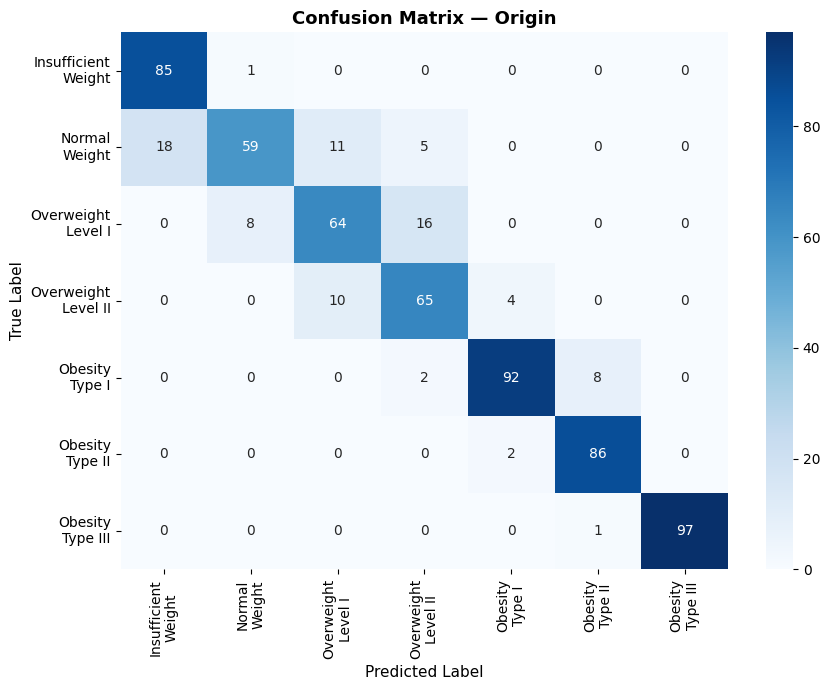

In [132]:
X_train_origin = pd.read_csv("/content/X_train_scaled.csv")
y_train_origin = pd.read_csv("/content/y_train.csv")
X_test_origin = pd.read_csv("/content/X_test_scaled.csv")
y_test_origin = pd.read_csv("/content/y_test.csv")

model = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
model.fit(X_train_origin, y_train_origin.values.ravel())

y_pred = model.predict(X_test_origin)
results['Softmax Regression'] = evaluate('Origin', y_test_origin.values.ravel(), y_pred)

Xử lý với tệp dữ liệu đã PCA


  PCA
  Accuracy : 0.6688
  F1-score : 0.6603

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.58      0.71      0.64        86
           1       0.48      0.33      0.39        93
           2       0.57      0.50      0.53        88
           3       0.50      0.52      0.51        79
           4       0.65      0.67      0.66       102
           5       0.80      0.93      0.86        88
           6       1.00      0.99      0.99        98

    accuracy                           0.67       634
   macro avg       0.65      0.66      0.65       634
weighted avg       0.66      0.67      0.66       634



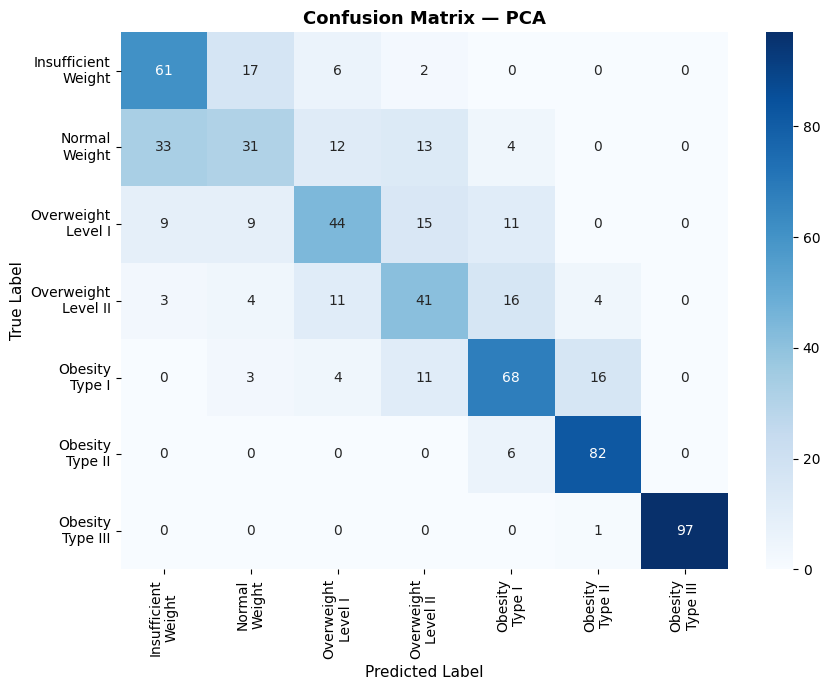

In [133]:
X_train_pca = pd.read_csv("/content/X_train_pca.csv")
X_test_pca = pd.read_csv("/content/X_test_pca.csv")

y_train_pca = X_train_pca.pop('NObeyesdad')
y_test_pca = X_test_pca.pop('NObeyesdad')

model = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
model.fit(X_train_pca, y_train_pca)

y_pred = model.predict(X_test_pca)

results['Softmax Regression PCA'] = evaluate('PCA', y_test_pca, y_pred)

Xử lý với tệp dữ liệu LDA

Trong quá trình xử lý dữ liệu sau khi áp dụng Linear Discriminant Analysis, nhóm đã tiến hành thử nghiệm mô hình với nhiều số chiều LD khác nhau, cụ thể từ 1 đến 6 thành phần.

Kết quả thực nghiệm cho thấy hiệu năng của mô hình thay đổi theo số lượng thành phần LDA được giữ lại. Trong đó, khi lựa chọn 5 thành phần LD, mô hình đạt được kết quả tốt nhất về mặt hiệu năng, cho thấy đây là mức tối ưu giúp cân bằng giữa việc giữ lại thông tin phân biệt giữa các lớp và hạn chế nhiễu trong dữ liệu.


  LDA
  Accuracy : 0.9290
  F1-score : 0.9292

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94        86
           1       0.93      0.82      0.87        93
           2       0.80      0.88      0.84        88
           3       0.88      0.89      0.88        79
           4       1.00      0.96      0.98       102
           5       0.97      1.00      0.98        88
           6       1.00      0.99      0.99        98

    accuracy                           0.93       634
   macro avg       0.93      0.93      0.93       634
weighted avg       0.93      0.93      0.93       634



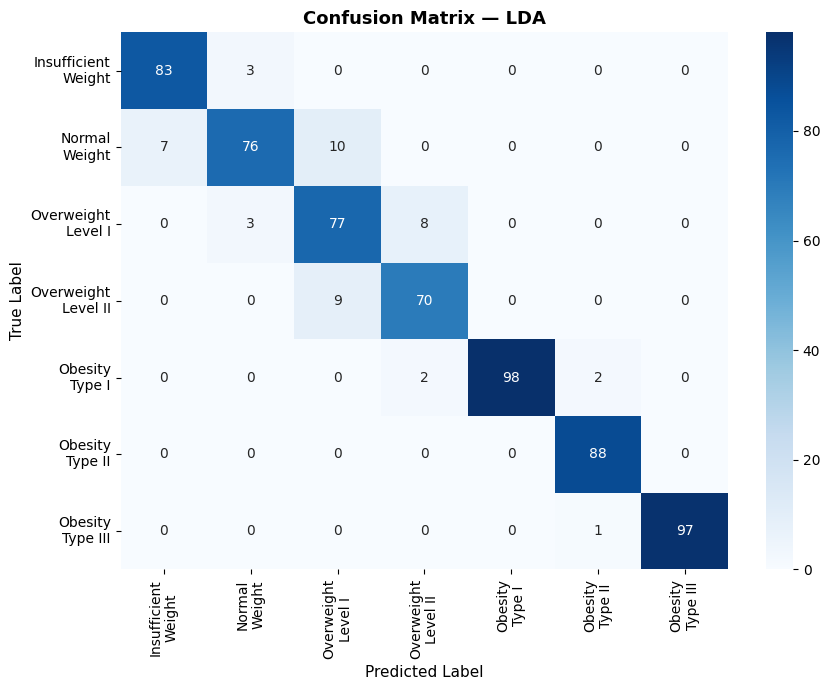

In [134]:
X_train_lda = pd.read_csv("/content/X_train_lda_5.csv")
X_test_lda  = pd.read_csv("/content/X_test_lda_5.csv")

y_train_lda = X_train_lda.pop('NObeyesdad')
y_test_lda  = X_test_lda.pop('NObeyesdad')

model = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
model.fit(X_train_lda, y_train_lda)

y_pred = model.predict(X_test_lda)

results['Softmax Regression LDA'] = evaluate('LDA', y_test_lda, y_pred)

So sánh kết quả thực hiện trên 3 tệp dữ liệu

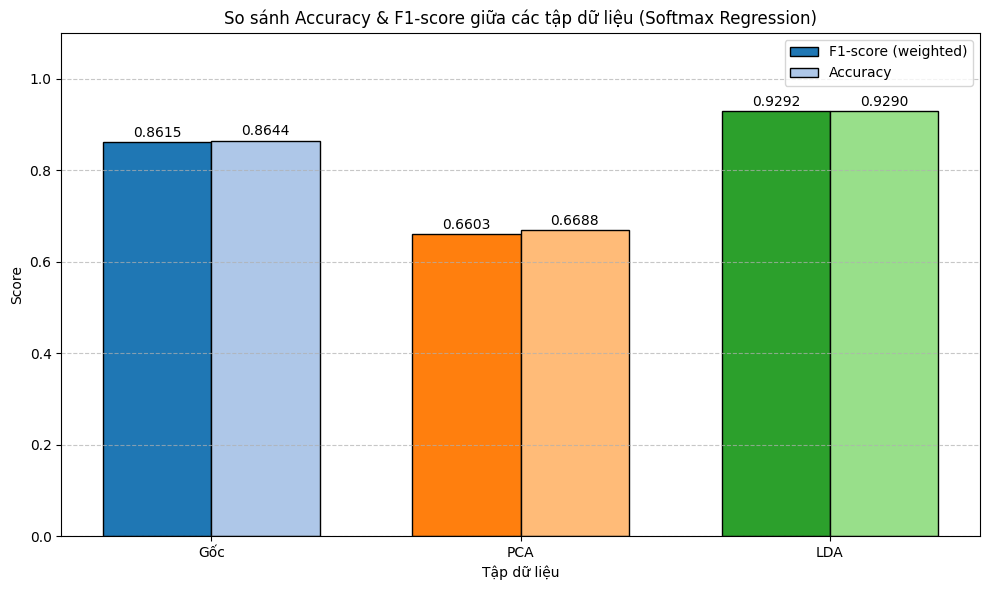

In [135]:
def plot_performance(results_dict):
    datasets = list(results_dict.keys())
    f1_scores = [results_dict[k][1] for k in datasets]
    accuracies = [results_dict[k][0] for k in datasets]

    x = np.arange(len(datasets))
    width = 0.35

    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(x - width/2, f1_scores, width, label='F1-score (weighted)',
                    color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
    bars2 = plt.bar(x + width/2, accuracies, width, label='Accuracy',
                    color=['#aec7e8', '#ffbb78', '#98df8a'], edgecolor='black')

    for bar in bars1:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
                 ha='center', va='bottom', fontsize=10)

    for bar in bars2:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
                 ha='center', va='bottom', fontsize=10)

    plt.title('So sánh Accuracy & F1-score giữa các tập dữ liệu (Softmax Regression)', fontsize=12)
    plt.xlabel('Tập dữ liệu', fontsize=10)
    plt.ylabel('Score', fontsize=10)
    plt.ylim(0, 1.1)
    plt.xticks(x, datasets)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

f1_scores_lr = {
    'Gốc': results['Softmax Regression'],
    'PCA': results['Softmax Regression PCA'],
    'LDA': results['Softmax Regression LDA']
}

plot_performance(f1_scores_lr)

##Support Vector Machine

In [136]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, f1_score,accuracy_score,precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')

In [137]:
class_names = [
    'Insufficient\nWeight',
    'Normal\nWeight',
    'Overweight\nLevel I',
    'Overweight\nLevel II',
    'Obesity\nType I',
    'Obesity\nType II',
    'Obesity\nType III',
]

custom_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#e377c2', '#8c564b', '#7f7f7f',
]

TARGET = "NObeyesdad"

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{title.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred))
    plot_confusion_matrix(y_true, y_pred, name)
    return acc, f1

results = {}


Xử lý với tệp dữ liệu gốc


  Dữ liệu gốc (Scaled)
  Accuracy : 0.9290
  F1-score : 0.9288

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        86
           1       0.89      0.85      0.87        93
           2       0.82      0.83      0.82        88
           3       0.88      0.87      0.88        79
           4       0.99      0.96      0.98       102
           5       0.98      1.00      0.99        88
           6       1.00      1.00      1.00        98

    accuracy                           0.93       634
   macro avg       0.93      0.93      0.93       634
weighted avg       0.93      0.93      0.93       634



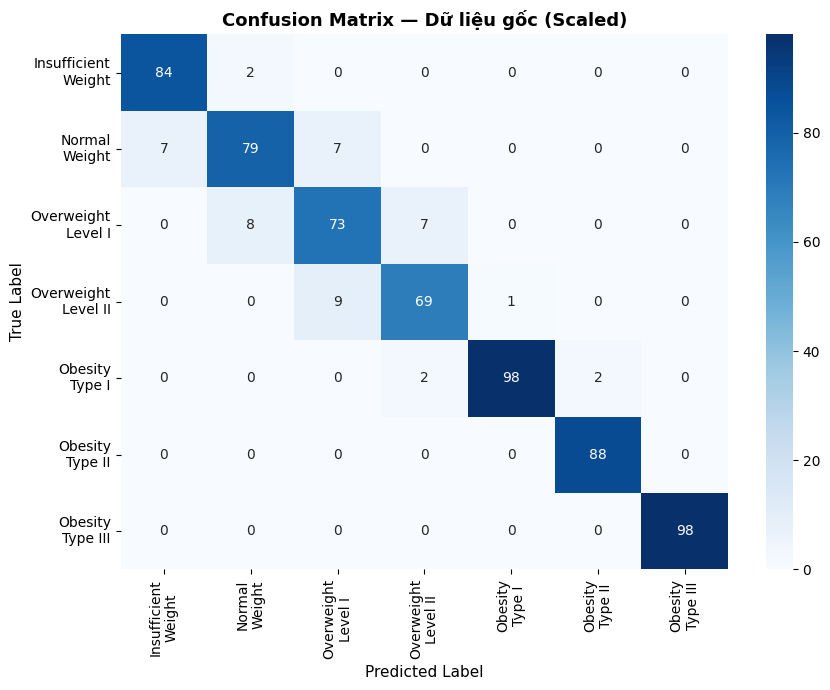

In [138]:
X_train_origin = pd.read_csv("/content/X_train_scaled.csv")
y_train_origin = pd.read_csv("/content/y_train.csv")
X_test_origin = pd.read_csv("/content/X_test_scaled.csv")
y_test_origin = pd.read_csv("/content/y_test.csv")

model = SVC(kernel="linear", C=1, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)
y_pred_raw = model.predict(X_test)

acc, f1 = evaluate("Dữ liệu gốc (Scaled)", y_test, y_pred_raw)
results["Gốc"] = {"Accuracy": acc, "F1-score": f1}


Xử lý với tệp dữ liệu PCA


  PCA
  Accuracy : 0.6972
  F1-score : 0.6899

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.56      0.81      0.67        86
           1       0.56      0.33      0.42        93
           2       0.56      0.52      0.54        88
           3       0.51      0.61      0.55        79
           4       0.84      0.66      0.74       102
           5       0.82      0.94      0.88        88
           6       1.00      0.99      0.99        98

    accuracy                           0.70       634
   macro avg       0.69      0.70      0.68       634
weighted avg       0.70      0.70      0.69       634



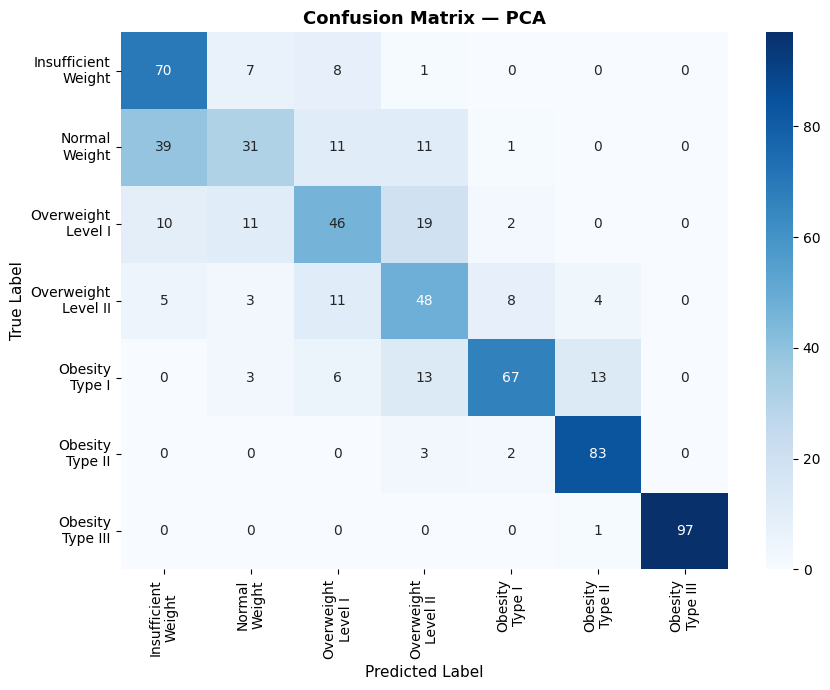

In [139]:
X_train_pca = pd.read_csv("/content/X_train_pca.csv")
X_test_pca = pd.read_csv("/content/X_test_pca.csv")

y_train_pca = X_train_pca.pop('NObeyesdad')
y_test_pca = X_test_pca.pop('NObeyesdad')

model_pca = SVC(kernel="linear", C=1, class_weight="balanced", random_state=42)
model_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = model_pca.predict(X_test_pca)

acc, f1 = evaluate("PCA", y_test_pca, y_pred_pca)
results["PCA"] = {"Accuracy": acc, "F1-score": f1}

Xử lý với tệp dữ liệu LDA


  LDA
  Accuracy : 0.9290
  F1-score : 0.9288

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        86
           1       0.89      0.85      0.87        93
           2       0.82      0.83      0.82        88
           3       0.88      0.87      0.88        79
           4       0.99      0.96      0.98       102
           5       0.98      1.00      0.99        88
           6       1.00      1.00      1.00        98

    accuracy                           0.93       634
   macro avg       0.93      0.93      0.93       634
weighted avg       0.93      0.93      0.93       634



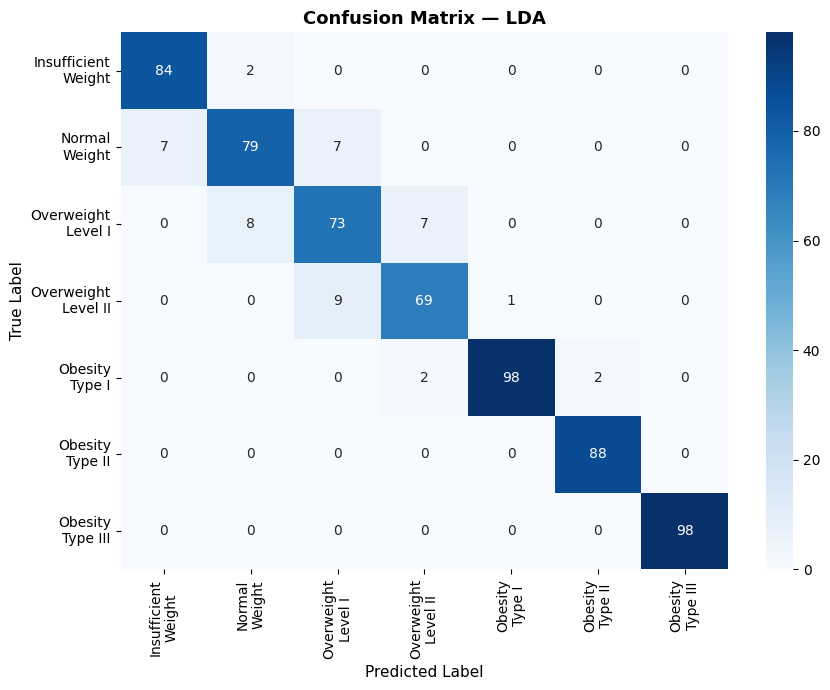

In [140]:
X_train_lda = pd.read_csv("/content/X_train_lda_6.csv")
X_test_lda  = pd.read_csv("/content/X_test_lda_6.csv")

y_train_lda = X_train_lda.pop('NObeyesdad')
y_test_lda  = X_test_lda.pop('NObeyesdad')

model_lda = SVC(kernel="linear", C=1, class_weight="balanced", random_state=42)
model_lda.fit(X_train_lda, y_train_lda)
y_pred_lda = model_lda.predict(X_test_lda)

acc, f1 = evaluate("LDA", y_test_lda, y_pred_lda)
results["LDA"] = {"Accuracy": acc, "F1-score": f1}

So sánh kết quả thực hiện trên 3 tệp dữ liệu

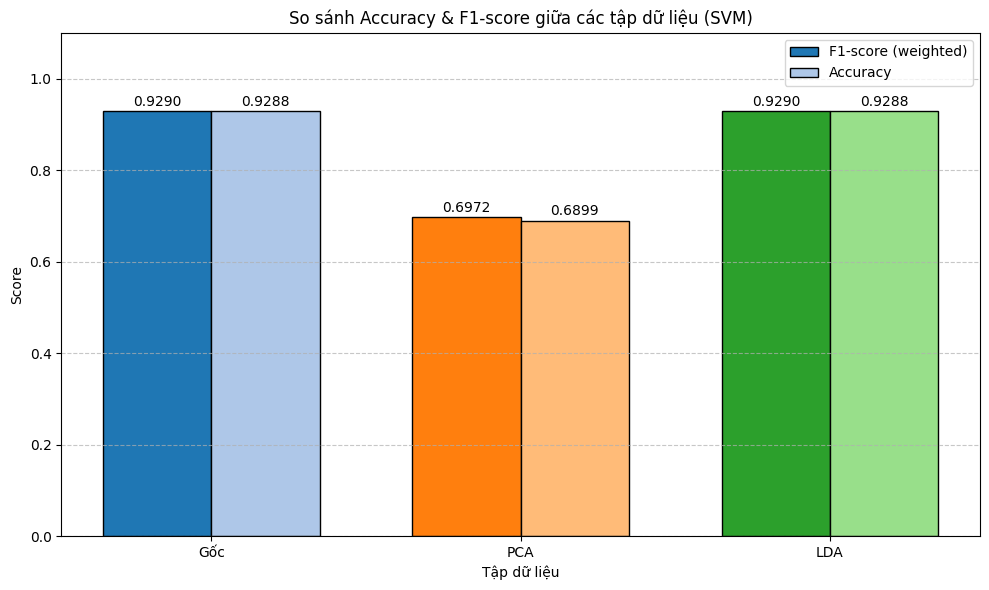

In [141]:
def plot_performance(results_dict):
    datasets = list(results_dict.keys())
    f1_scores = [results_dict[k]["Accuracy"] for k in datasets]
    accuracies = [results_dict[k]["F1-score"] for k in datasets]

    x = np.arange(len(datasets))
    width = 0.35

    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(x - width/2, f1_scores, width, label='F1-score (weighted)',
                    color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
    bars2 = plt.bar(x + width/2, accuracies, width, label='Accuracy',
                    color=['#aec7e8', '#ffbb78', '#98df8a'], edgecolor='black')

    for bar in bars1:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
                 ha='center', va='bottom', fontsize=10)

    for bar in bars2:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
                 ha='center', va='bottom', fontsize=10)

    plt.title('So sánh Accuracy & F1-score giữa các tập dữ liệu (SVM)', fontsize=12)
    plt.xlabel('Tập dữ liệu', fontsize=10)
    plt.ylabel('Score', fontsize=10)
    plt.ylim(0, 1.1)
    plt.xticks(x, datasets)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

f1_scores_lr = {
    'Gốc': results['Gốc'],
    'PCA': results['PCA'],
    'LDA': results['LDA']
}

plot_performance(f1_scores_lr)

##K-Nearest Neighbours

In [142]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score,accuracy_score,precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')

In [143]:
class_names = [
    'Insufficient\nWeight',
    'Normal\nWeight',
    'Overweight\nLevel I',
    'Overweight\nLevel II',
    'Obesity\nType I',
    'Obesity\nType II',
    'Obesity\nType III',
]

custom_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#e377c2', '#8c564b', '#7f7f7f',
]

TARGET = "NObeyesdad"

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{title.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred))
    plot_confusion_matrix(y_true, y_pred, name)
    return acc, f1

results = {}


Xử lý với tệp dữ liệu gốc


  Dữ liệu gốc (Scaled)
  Accuracy : 0.8297
  F1-score : 0.8218

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.74      0.97      0.84        86
           1       0.76      0.52      0.62        93
           2       0.83      0.66      0.73        88
           3       0.79      0.76      0.77        79
           4       0.79      0.90      0.84       102
           5       0.92      0.99      0.95        88
           6       0.97      1.00      0.98        98

    accuracy                           0.83       634
   macro avg       0.83      0.83      0.82       634
weighted avg       0.83      0.83      0.82       634



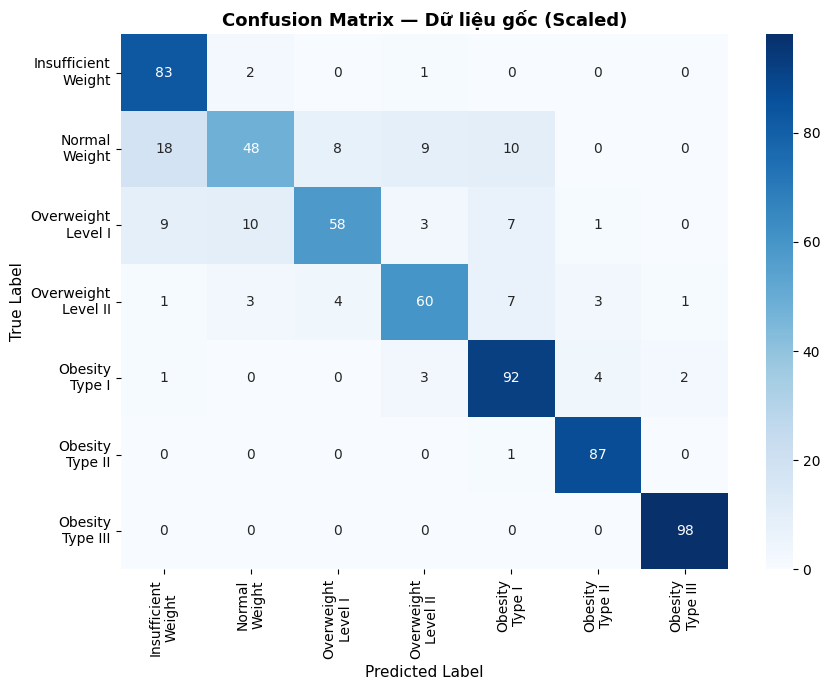

In [144]:
X_train_origin = pd.read_csv("/content/X_train_scaled.csv")
y_train_origin = pd.read_csv("/content/y_train.csv")
X_test_origin = pd.read_csv("/content/X_test_scaled.csv")
y_test_origin = pd.read_csv("/content/y_test.csv")

model = KNeighborsClassifier(n_neighbors=11, metric="manhattan", weights="uniform")
model.fit(X_train_origin, y_train_origin.values.ravel())
y_pred_raw = model.predict(X_test_origin)

acc, f1 = evaluate("Dữ liệu gốc (Scaled)", y_test_origin, y_pred_raw)
results["Gốc"] = {"Accuracy": acc, "F1-score": f1}

Xử lý với tệp dữ liệu PCA


  PCA
  Accuracy : 0.7350
  F1-score : 0.7206

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.64      0.90      0.74        86
           1       0.65      0.34      0.45        93
           2       0.80      0.56      0.66        88
           3       0.63      0.66      0.65        79
           4       0.69      0.73      0.71       102
           5       0.76      0.95      0.84        88
           6       0.95      1.00      0.98        98

    accuracy                           0.74       634
   macro avg       0.73      0.73      0.72       634
weighted avg       0.74      0.74      0.72       634



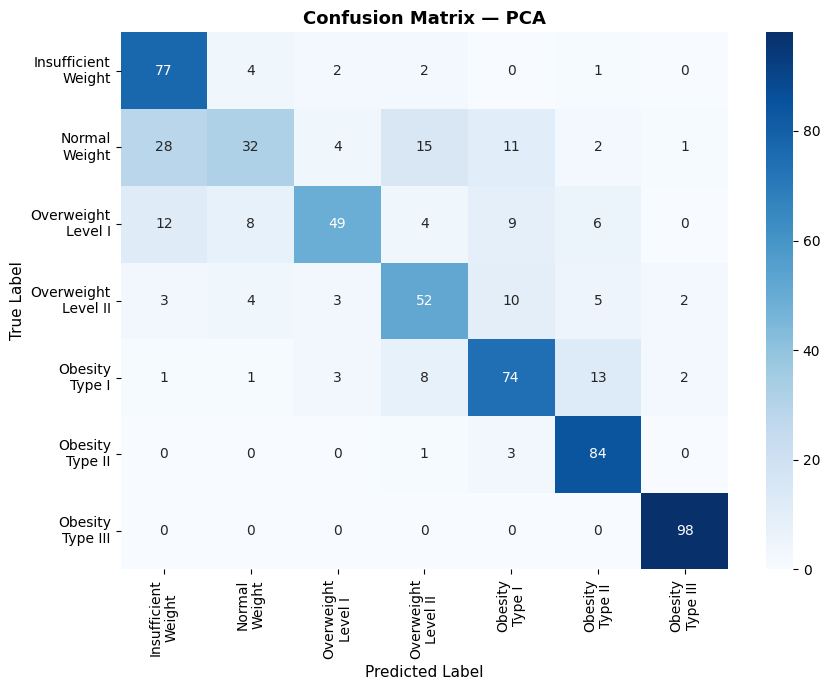

In [145]:
X_train_pca = pd.read_csv("/content/X_train_pca.csv")
X_test_pca = pd.read_csv("/content/X_test_pca.csv")

y_train_pca = X_train_pca.pop('NObeyesdad')
y_test_pca = X_test_pca.pop('NObeyesdad')

model_pca = KNeighborsClassifier(n_neighbors=11, metric="manhattan", weights="uniform")
model_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = model_pca.predict(X_test_pca)

acc, f1 = evaluate("PCA", y_test_pca, y_pred_pca)
results["PCA"] = {"Accuracy": acc, "F1-score": f1}

Xử lý với tệp dữ liệu LDA


  LDA
  Accuracy : 0.9101
  F1-score : 0.9090

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.98      0.91        86
           1       0.86      0.72      0.78        93
           2       0.79      0.83      0.81        88
           3       0.89      0.89      0.89        79
           4       0.98      0.96      0.97       102
           5       0.99      0.99      0.99        88
           6       1.00      1.00      1.00        98

    accuracy                           0.91       634
   macro avg       0.91      0.91      0.91       634
weighted avg       0.91      0.91      0.91       634



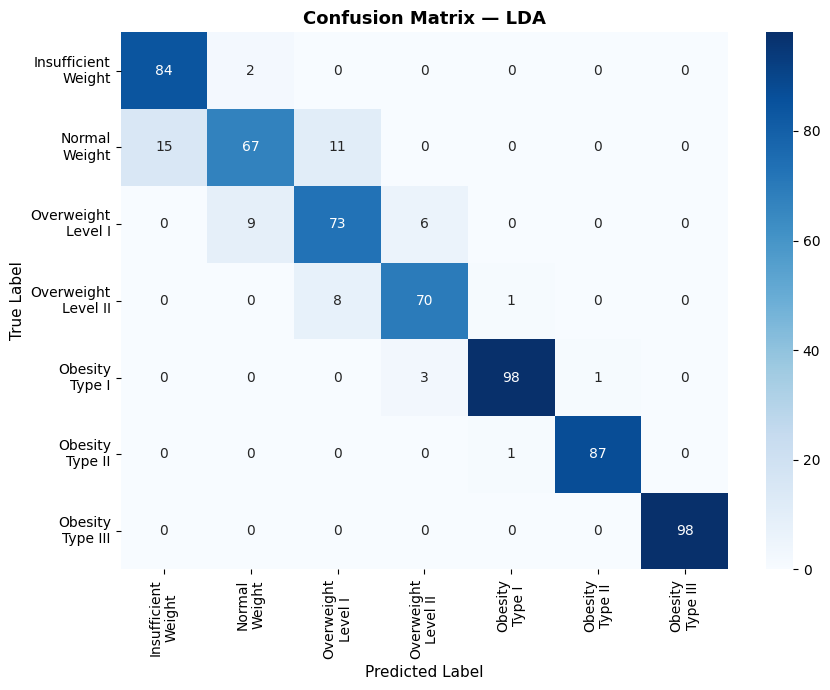

In [146]:
X_train_lda = pd.read_csv("/content/X_train_lda_6.csv")
X_test_lda = pd.read_csv("/content/X_test_lda_6.csv")

y_train_lda = X_train_lda.pop('NObeyesdad')
y_test_lda = X_test_lda.pop('NObeyesdad')

model_lda = KNeighborsClassifier(n_neighbors=11, metric="manhattan", weights="uniform")
model_lda.fit(X_train_lda, y_train_lda)
y_pred_lda = model_lda.predict(X_test_lda)

acc, f1 = evaluate("LDA", y_test_lda, y_pred_lda)
results["LDA"] = {"Accuracy": acc, "F1-score": f1}

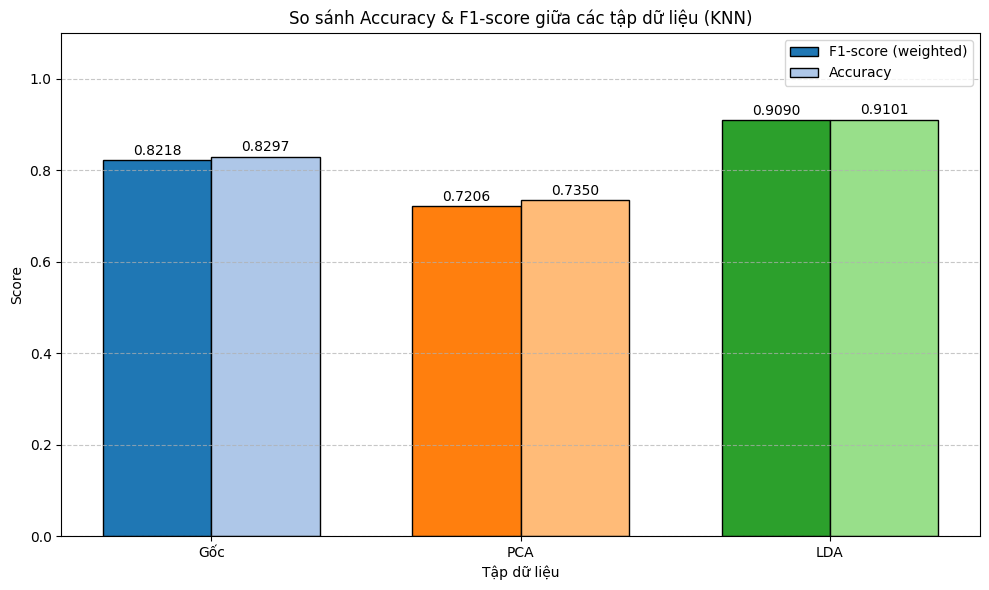

In [147]:
def plot_performance(results_dict):
    datasets = list(results_dict.keys())
    f1_scores = [results_dict[k]["F1-score"] for k in datasets]
    accuracies = [results_dict[k]["Accuracy"] for k in datasets]

    x = np.arange(len(datasets))
    width = 0.35

    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(x - width/2, f1_scores, width, label='F1-score (weighted)',
                    color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
    bars2 = plt.bar(x + width/2, accuracies, width, label='Accuracy',
                    color=['#aec7e8', '#ffbb78', '#98df8a'], edgecolor='black')

    for bar in bars1:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
                 ha='center', va='bottom', fontsize=10)

    for bar in bars2:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
                 ha='center', va='bottom', fontsize=10)

    plt.title('So sánh Accuracy & F1-score giữa các tập dữ liệu (KNN)', fontsize=12)
    plt.xlabel('Tập dữ liệu', fontsize=10)
    plt.ylabel('Score', fontsize=10)
    plt.ylim(0, 1.1)
    plt.xticks(x, datasets)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

f1_scores_lr = {
    'Gốc': results['Gốc'],
    'PCA': results['PCA'],
    'LDA': results['LDA']
}

plot_performance(f1_scores_lr)

##Kết quả thực nghiệm

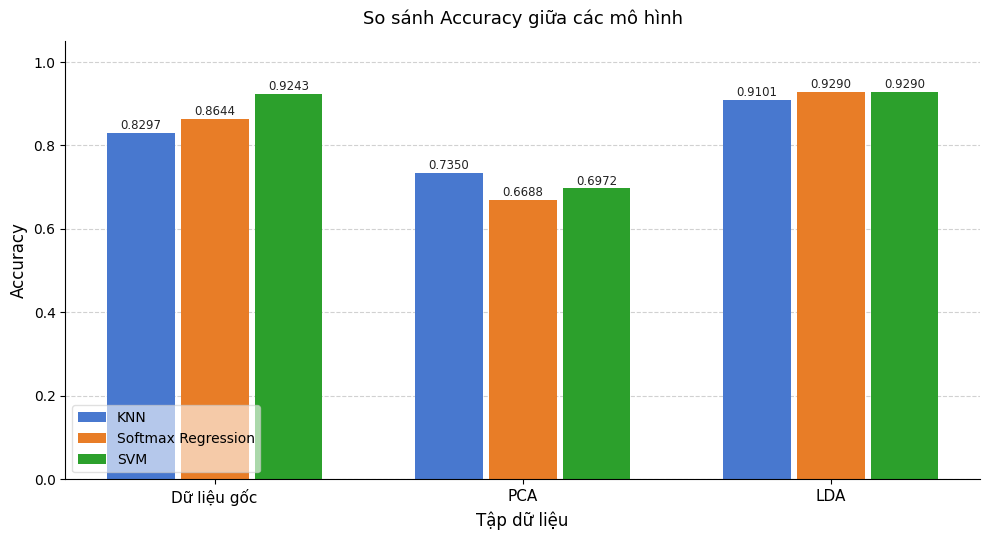

Đã lưu: bieu_do_cot.png


In [148]:
import matplotlib.pyplot as plt
import numpy as np

models = ["KNN", "Softmax Regression", "SVM"]
colors = ["#4878CF", "#E87D27", "#2CA02C"]

groups = ["Dữ liệu gốc", "PCA", "LDA"]

values = {
    "Dữ liệu gốc": [0.8297, 0.8644 , 0.9243],
    "PCA":          [0.7350, 0.6688, 0.6972],
    "LDA":          [0.9101,  0.9290, 0.9290],
}

x = np.arange(len(groups))
n = len(models)
bar_width = 0.22
gap = 0.02

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - (n - 1) / 2) * (bar_width + gap)
    vals = [values[g][i] for g in groups]
    bars = ax.bar(x + offset, vals, width=bar_width, label=model, color=color)

    # Nhãn số trên đầu mỗi cột
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.4f}",
            ha="center", va="bottom",
            fontsize=8.5, color="#222"
        )

# Trục & định dạng
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xlabel("Tập dữ liệu", fontsize=12)
ax.set_title("So sánh Accuracy giữa các mô hình", fontsize=13, pad=12)

# Grid ngang nét đứt
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, color="#ccc", alpha=0.9)
ax.set_axisbelow(True)

# Bỏ viền phải và trên
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="lower left", fontsize=10, framealpha=0.6)

plt.tight_layout()
plt.savefig("bieu_do_cot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu: bieu_do_cot.png")

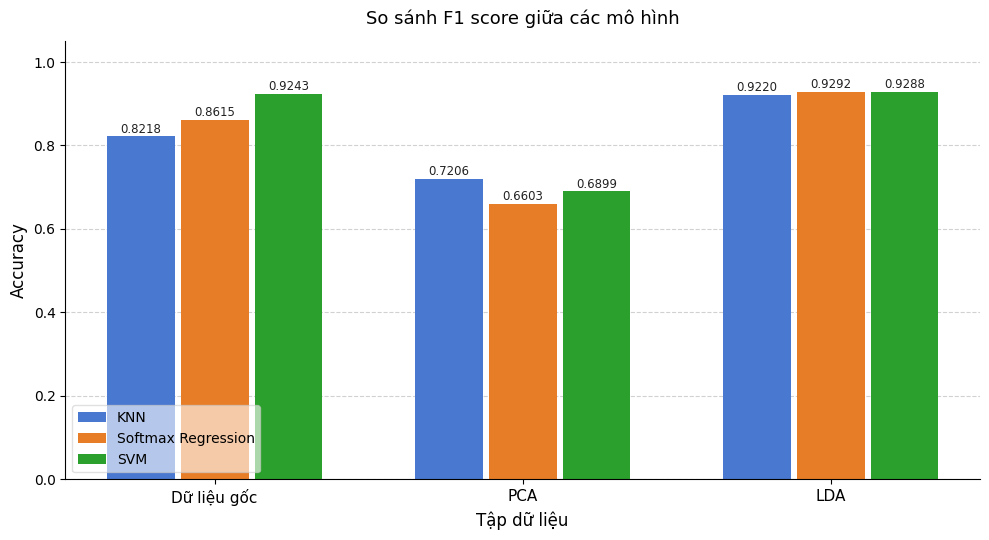

Đã lưu: bieu_do_cot.png


In [149]:
import matplotlib.pyplot as plt
import numpy as np

models = ["KNN", "Softmax Regression", "SVM"]
colors = ["#4878CF", "#E87D27", "#2CA02C"]

groups = ["Dữ liệu gốc", "PCA", "LDA"]


values = {
    "Dữ liệu gốc": [0.8218 , 0.8615   , 0.9243 ],
    "PCA":          [0.7206, 0.6603, 0.6899],
    "LDA":          [0.9220, 0.9292, 0.9288],
}


x = np.arange(len(groups))
n = len(models)
bar_width = 0.22
gap = 0.02

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - (n - 1) / 2) * (bar_width + gap)
    vals = [values[g][i] for g in groups]
    bars = ax.bar(x + offset, vals, width=bar_width, label=model, color=color)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.4f}",
            ha="center", va="bottom",
            fontsize=8.5, color="#222"
        )


ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xlabel("Tập dữ liệu", fontsize=12)
ax.set_title("So sánh F1 score giữa các mô hình", fontsize=13, pad=12)

ax.yaxis.grid(True, linestyle="--", linewidth=0.8, color="#ccc", alpha=0.9)
ax.set_axisbelow(True)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="lower left", fontsize=10, framealpha=0.6)

plt.tight_layout()
plt.savefig("bieu_do_cot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu: bieu_do_cot.png")

#PHẦN IV. MÔ HÌNH PHÂN CỤM KMEANS


Trong phần này, nhóm tiến hành áp dụng thuật toán K-Means Clustering nhằm khám phá cấu trúc phân bố tự nhiên của bộ dữ liệu Obesity sau khi dữ liệu đã được chuẩn hóa. Mục tiêu của phương pháp là kiểm tra xem các mẫu dữ liệu có thể tự động hình thành các cụm tương ứng với các mức độ béo phì hay không mà không sử dụng nhãn lớp trong quá trình huấn luyện.

Thuật toán K-Means là một phương pháp phân cụm không giám sát (unsupervised learning), hoạt động bằng cách chia tập dữ liệu thành K cụm sao cho khoảng cách giữa các điểm dữ liệu và tâm cụm (centroid) của cụm mà chúng thuộc về là nhỏ nhất. Trong nghiên cứu này, nhóm sử dụng khoảng giá trị số cụm từ K = 2 đến K = 11 để đánh giá chất lượng phân cụm.

Để lựa chọn số cụm tối ưu, nhóm sử dụng đồng thời nhiều tiêu chí đánh giá gồm:

* Inertia (Elbow Method): đo tổng khoảng cách bình phương từ các điểm dữ liệu tới tâm cụm.
* Silhouette Score: đánh giá mức độ tách biệt giữa các cụm; giá trị càng cao càng tốt.
* Davies-Bouldin Index (DBI): đo mức độ tương đồng giữa các cụm; giá trị càng thấp càng tốt.
* Adjusted Rand Index (ARI): so sánh mức độ tương đồng giữa kết quả phân cụm và nhãn thực tế của dữ liệu.

Sau khi xác định số cụm tối ưu theo Silhouette Score và DBI, nhóm tiến hành huấn luyện mô hình K-Means cuối cùng và trực quan hóa kết quả phân cụm bằng phương pháp giảm chiều PCA xuống 2 thành phần chính để dễ quan sát.

Ngoài ra, nhóm còn phân tích “dominant label” của từng cụm bằng cách xác định nhãn thực tế xuất hiện nhiều nhất trong mỗi cụm nhằm đánh giá mức độ tương ứng giữa phân cụm tự động và các mức độ béo phì trong dữ liệu gốc.

Thông qua quá trình này, nhóm có thể đánh giá khả năng của K-Means trong việc phát hiện cấu trúc tiềm ẩn của dữ liệu Obesity cũng như mức độ phân tách tự nhiên giữa các nhóm người dùng theo tình trạng cân nặng và béo phì.

Trong số các tiêu chí, Silhouette Score được chọn làm tiêu chí quyết định
chính để xác định K_BEST, trong khi DBI được dùng để đối chiếu,
và biểu đồ so sánh trực quan giữa hai giá trị K tối ưu theo
Silhouette và DBI cũng được trình bày đồng thời.

In [150]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import display, Image
import warnings
warnings.filterwarnings('ignore')


  K |    Inertia | Silhouette |      DBI
------------------------------------------
  2 |    33564.6 |     0.2784 |   1.5180 ◄ Best Silhouette ◄ Best DBI
  3 |    30386.6 |     0.1786 |   2.2104
  4 |    28299.5 |     0.1540 |   2.0471
  5 |    26479.8 |     0.1615 |   1.8940
  6 |    24883.1 |     0.1515 |   1.8499
  7 |    23802.4 |     0.1528 |   1.8560
  8 |    23293.4 |     0.1376 |   2.1500
  9 |    21609.0 |     0.1606 |   1.8776
 10 |    20890.9 |     0.1618 |   1.8926
 11 |    20517.9 |     0.1616 |   1.8720

Best K by Silhouette : 2
Best K by DBI        : 2
Chosen K (= Best Silhouette) : 2

[K=2] Silhouette=0.2784 | ARI=0.0101 | DBI=1.5180 | Inertia=33564.6

Dominant True Label per Cluster:
  Cluster 0 (n=1685) → [6] Obesity III
  Cluster 1 (n= 426) → [4] Obesity I

Saved → kmeans_result_original.csv


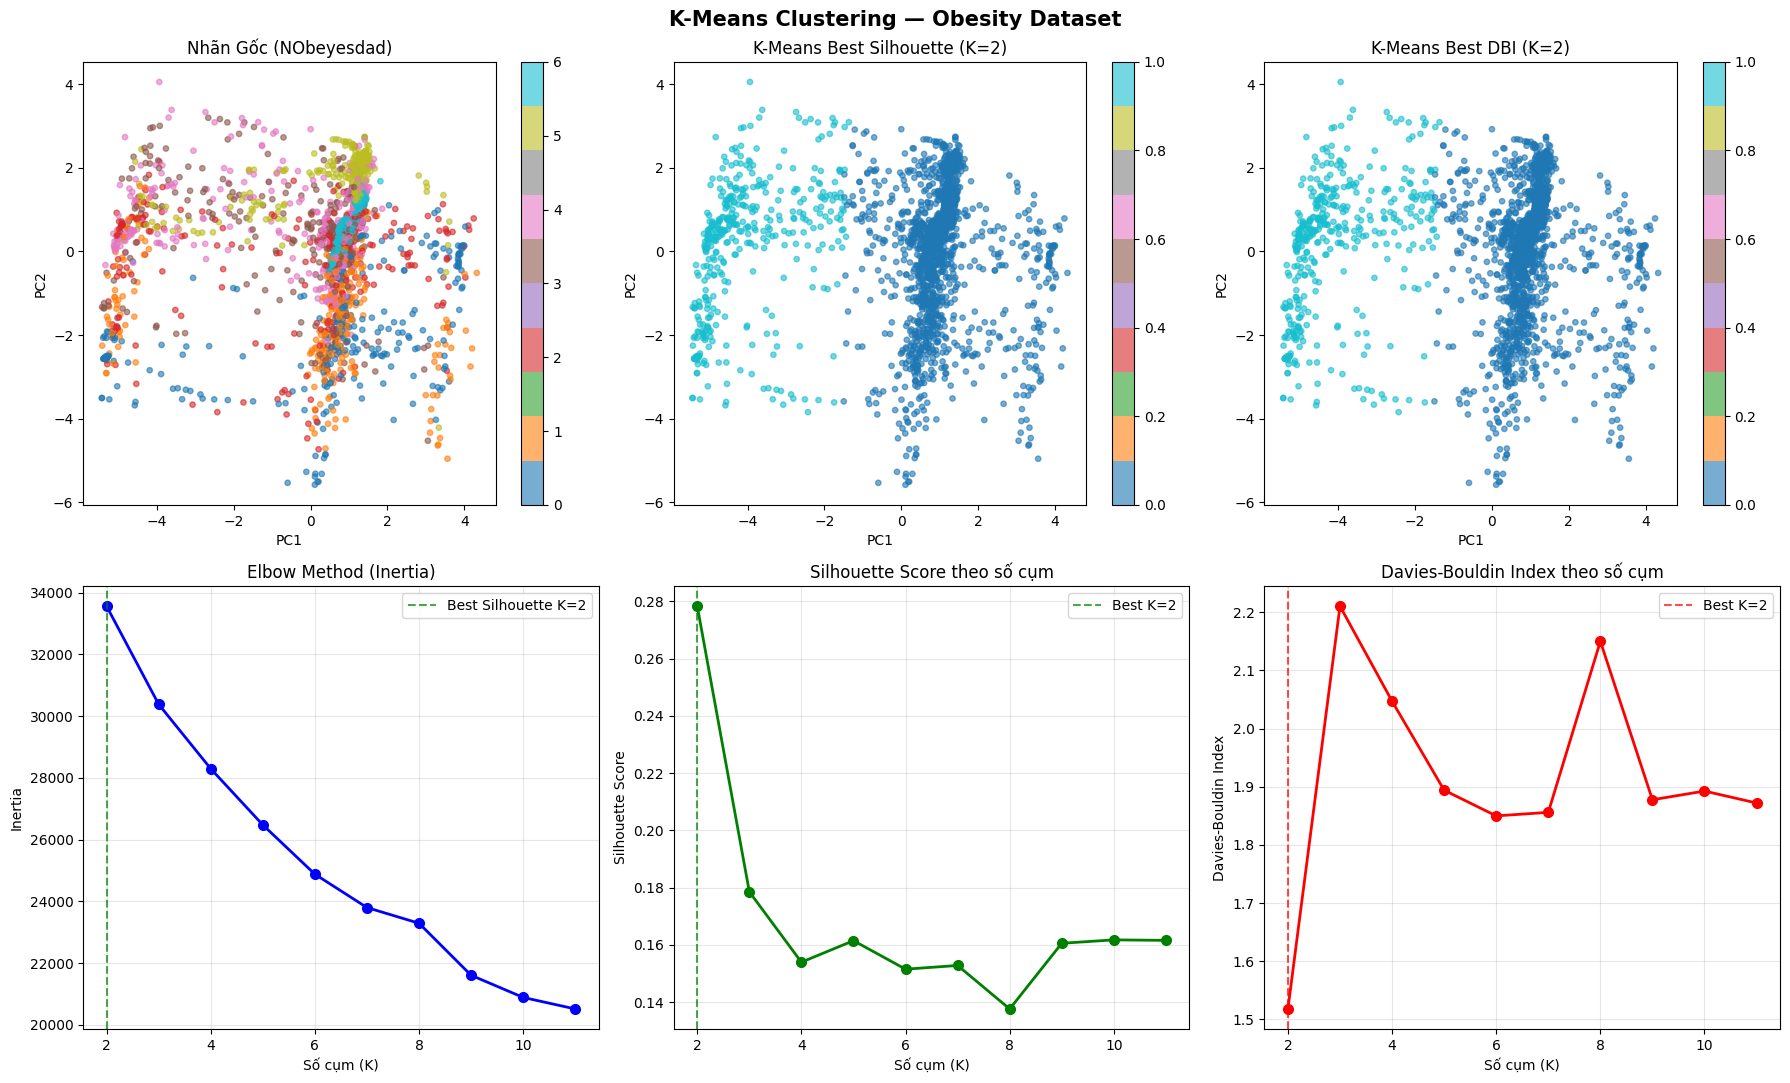

In [98]:
X_train = pd.read_csv("X_train_scaled.csv")
X_test  = pd.read_csv("X_test_scaled.csv")
y_train = pd.read_csv("y_train.csv")
y_test  = pd.read_csv("y_test.csv")

TARGET  = "NObeyesdad"
K_RANGE = range(2, 12)
RANDOM  = 42

LABEL_MAP = {
    0: "Insufficient Weight",
    1: "Normal Weight",
    2: "Overweight I",
    3: "Overweight II",
    4: "Obesity I",
    5: "Obesity II",
    6: "Obesity III",
}

X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)[TARGET].values

inertias, silhouettes, dbis = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM, n_init=10)
    labels = km.fit_predict(X_all)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_all, labels))
    dbis.append(davies_bouldin_score(X_all, labels))

best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]
best_k_dbi = list(K_RANGE)[np.argmin(dbis)]

K_BEST = best_k_sil

print(f"\n{'K':>3} | {'Inertia':>10} | {'Silhouette':>10} | {'DBI':>8}")
print("-" * 42)
for k, ine, sil, dbi in zip(K_RANGE, inertias, silhouettes, dbis):
    tag = ""
    if k == best_k_sil:
        tag += " ◄ Best Silhouette"
    if k == best_k_dbi:
        tag += " ◄ Best DBI"
    print(f"{k:3d} | {ine:10.1f} | {sil:10.4f} | {dbi:8.4f}{tag}")

print(f"\nBest K by Silhouette : {best_k_sil}")
print(f"Best K by DBI        : {best_k_dbi}")
print(f"Chosen K (= Best Silhouette) : {K_BEST}")

km_final = KMeans(n_clusters=K_BEST, random_state=RANDOM, n_init=10)
cluster_labels = km_final.fit_predict(X_all)

sil_final = silhouette_score(X_all, cluster_labels)
ari_final = adjusted_rand_score(y_all, cluster_labels)
dbi_final = davies_bouldin_score(X_all, cluster_labels)

print(f"\n[K={K_BEST}] Silhouette={sil_final:.4f} | ARI={ari_final:.4f} | "
      f"DBI={dbi_final:.4f} | Inertia={km_final.inertia_:.1f}")

df_result = X_all.copy()
df_result["cluster"]    = cluster_labels
df_result["true_label"] = y_all

print("\nDominant True Label per Cluster:")
for c in range(K_BEST):
    sub = df_result[df_result["cluster"] == c]["true_label"]
    dom = int(sub.mode()[0])
    print(f"  Cluster {c} (n={len(sub):4d}) → [{dom}] {LABEL_MAP.get(dom, dom)}")

df_result.to_csv("kmeans_result_original.csv", index=False)
print("\nSaved → kmeans_result_original.csv")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

km_dbi = KMeans(n_clusters=best_k_dbi, random_state=RANDOM, n_init=10)
labels_dbi = km_dbi.fit_predict(X_all)

k_list = list(K_RANGE)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("K-Means Clustering — Obesity Dataset", fontsize=15, fontweight="bold")

sc1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_all,
                          cmap="tab10", alpha=0.6, s=15)
axes[0, 0].set_title("Nhãn Gốc (NObeyesdad)")
axes[0, 0].set_xlabel("PC1")
axes[0, 0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0, 0])

# 2. K-means K_BEST (= best Silhouette)
sc2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                          cmap="tab10", alpha=0.6, s=15)
axes[0, 1].set_title(f"K-Means Best Silhouette (K={K_BEST})")
axes[0, 1].set_xlabel("PC1")
axes[0, 1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[0, 1])

# 3. K-means best DBI
sc3 = axes[0, 2].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbi,
                          cmap="tab10", alpha=0.6, s=15)
axes[0, 2].set_title(f"K-Means Best DBI (K={best_k_dbi})")
axes[0, 2].set_xlabel("PC1")
axes[0, 2].set_ylabel("PC2")
plt.colorbar(sc3, ax=axes[0, 2])

# 4. Elbow (Inertia)
axes[1, 0].plot(k_list, inertias, "bo-", linewidth=2, markersize=7)
axes[1, 0].axvline(x=K_BEST, color="green", linestyle="--", alpha=0.7,
                   label=f"Best Silhouette K={K_BEST}")
axes[1, 0].set_xlabel("Số cụm (K)")
axes[1, 0].set_ylabel("Inertia")
axes[1, 0].set_title("Elbow Method (Inertia)")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 5. Silhouette Score
axes[1, 1].plot(k_list, silhouettes, "go-", linewidth=2, markersize=7)
axes[1, 1].axvline(x=best_k_sil, color="green", linestyle="--", alpha=0.7,
                   label=f"Best K={best_k_sil}")
axes[1, 1].set_xlabel("Số cụm (K)")
axes[1, 1].set_ylabel("Silhouette Score")
axes[1, 1].set_title("Silhouette Score theo số cụm")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# 6. Davies-Bouldin Index
axes[1, 2].plot(k_list, dbis, "ro-", linewidth=2, markersize=7)
axes[1, 2].axvline(x=best_k_dbi, color="red", linestyle="--", alpha=0.7,
                   label=f"Best K={best_k_dbi}")
axes[1, 2].set_xlabel("Số cụm (K)")
axes[1, 2].set_ylabel("Davies-Bouldin Index")
axes[1, 2].set_title("Davies-Bouldin Index theo số cụm")
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.savefig("kmeans_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

#PHẦN V. CHUYỂN MÔ HÌNH PHÂN LOẠI VỀ HỒI QUY

##Support Vector Machine

Trong phần này, nhóm thực hiện chuyển đổi bài toán phân loại bằng Support Vector Machine (SVM) sang dạng hồi quy bằng cách khai thác giá trị decision function của mô hình phân loại. Thay vì chỉ sử dụng nhãn dự đoán rời rạc, phương pháp này tận dụng thông tin liên tục mà SVM sinh ra để xây dựng một bài toán hồi quy trên không gian đặc trưng của mô hình.

Cụ thể, sau khi huấn luyện mô hình SVM Classification trên dữ liệu Obesity, nhóm sử dụng hàm `decision_function()` để thu được các giá trị score biểu diễn mức độ tin cậy của mô hình đối với từng mẫu dữ liệu. Các decision score này phản ánh khoảng cách tương đối của điểm dữ liệu tới siêu phẳng phân tách (hyperplane) của SVM, do đó mang tính liên tục và phù hợp cho bài toán hồi quy.

Đối với trường hợp phân loại đa lớp, `decision_function()` tạo ra nhiều chiều score tương ứng với các lớp khác nhau. Để chuyển các score này về dạng một chiều phục vụ hồi quy, nhóm áp dụng phương pháp PCA nhằm giảm chiều decision space xuống còn một thành phần chính duy nhất nhưng vẫn giữ lại phần lớn thông tin biến thiên quan trọng.

Sau đó, mô hình Support Vector Regression (SVR) với kernel RBF được sử dụng để học và dự đoán các decision score liên tục này. Kết quả hồi quy được đánh giá bằng các chỉ số:

* Mean Squared Error (MSE)
* Hệ số xác định (R^2)

Ngoài ra, nhóm trực quan hóa mối quan hệ giữa decision score thực tế của SVM và giá trị dự đoán bởi SVR thông qua biểu đồ scatter plot cùng đường tham chiếu lý tưởng (y=x). Điều này giúp đánh giá khả năng của SVR trong việc xấp xỉ lại không gian quyết định của mô hình SVM Classification.

Phương pháp này cho phép chuyển bài toán phân loại sang dạng hồi quy mà vẫn bảo toàn thông tin quyết định nội tại của mô hình SVM, đồng thời phản ánh mức độ liên tục giữa các lớp dữ liệu trong bài toán Obesity.


In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC, SVR
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

In [152]:
y_train = pd.read_csv("/content/y_train.csv")
y_test = pd.read_csv("/content/y_test.csv")
X_train_orig = pd.read_csv("/content/X_train_scaled.csv")
X_test_orig  = pd.read_csv("/content/X_test_scaled.csv")
X_train_pca = pd.read_csv("/content/X_train_pca.csv")
X_test_pca = pd.read_csv("/content/X_test_pca.csv")
X_train_lda = pd.read_csv("/content/X_train_lda_5.csv")
X_test_lda = pd.read_csv("/content/X_test_lda_5.csv")


for df in [X_train_pca, X_test_pca, X_train_lda, X_test_lda]:
    if 'NObeyesdad' in df.columns:
        df.drop('NObeyesdad', axis=1, inplace=True)

def svm_regression_on_decision_values(X_train, X_test, y_train, y_test, svm_model, dataset_name):

    y_train_1d = y_train.values.ravel()
    y_test_1d = y_test.values.ravel()

    df_train = svm_model.decision_function(X_train)
    df_test = svm_model.decision_function(X_test)

    print("\nShape decision_function:", df_train.shape)

    if df_train.ndim == 2:

        print("Áp dụng PCA cho decision_function...")

        pca = PCA(n_components=1)

        y_train_score = pca.fit_transform(df_train).ravel()
        y_test_score = pca.transform(df_test).ravel()

    else:

        y_train_score = df_train
        y_test_score = df_test

    svr = SVR(kernel='rbf', C=10, epsilon=0.1)

    svr.fit(X_train, y_train_score)

    y_pred = svr.predict(X_test)

    mse = mean_squared_error(y_test_score, y_pred)
    r2 = r2_score(y_test_score, y_pred)

    print(f"\n[Hồi quy SVM] - {dataset_name}")
    print(f"MSE : {mse:.4f}")
    print(f"R²  : {r2:.4f}")

    plt.figure(figsize=(7, 6))

    sns.scatterplot(
        x=y_test_score,
        y=y_pred,
        hue=y_test_1d,
        palette='tab10',
        alpha=0.7,
        edgecolor='k'
    )

    min_val = min(y_test_score.min(), y_pred.min())
    max_val = max(y_test_score.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle='--',
        color='red',
        label='Ideal (y = x)'
    )

    plt.xlim(min_val - 1, max_val + 1)
    plt.ylim(min_val - 1, max_val + 1)

    plt.xlabel("Decision Function thực tế (PCA Reduced)")
    plt.ylabel("Dự đoán SVR")

    plt.title(f"Hồi quy SVM – {dataset_name}")

    plt.legend(title="Class")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return mse, r2





Thực hiện trên tập dữ liệu gốc


Shape decision_function: (1477, 7)
Áp dụng PCA cho decision_function...

[Hồi quy SVM] - Dữ liệu gốc
MSE : 0.2213
R²  : 0.9862


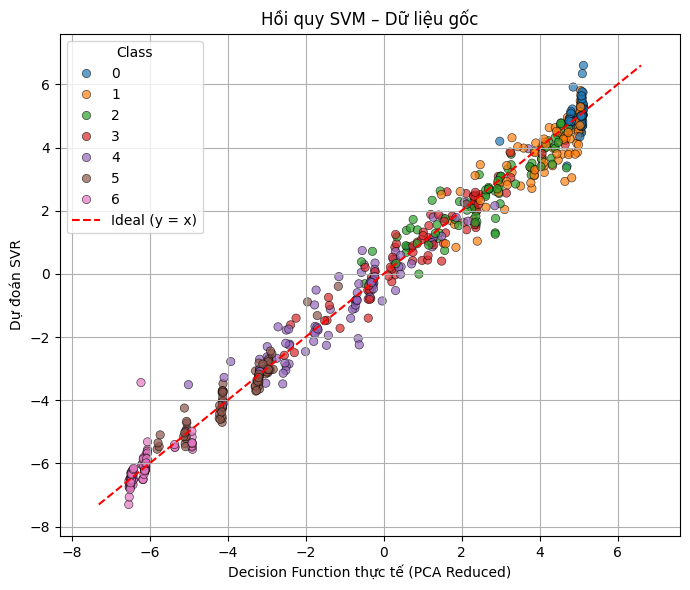

In [153]:
svm_orig = SVC(kernel="rbf", C=1, class_weight="balanced", random_state=42)
svm_orig.fit(X_train_orig, y_train.values.ravel())

mse_goc, r2_goc = svm_regression_on_decision_values(
    X_train_orig, X_test_orig, y_train, y_test, svm_orig, "Dữ liệu gốc"
)

thực hiện trên tập dữ liệu PCA


Shape decision_function: (1477, 7)
Áp dụng PCA cho decision_function...

[Hồi quy SVM] - PCA
MSE : 0.2215
R²  : 0.9828


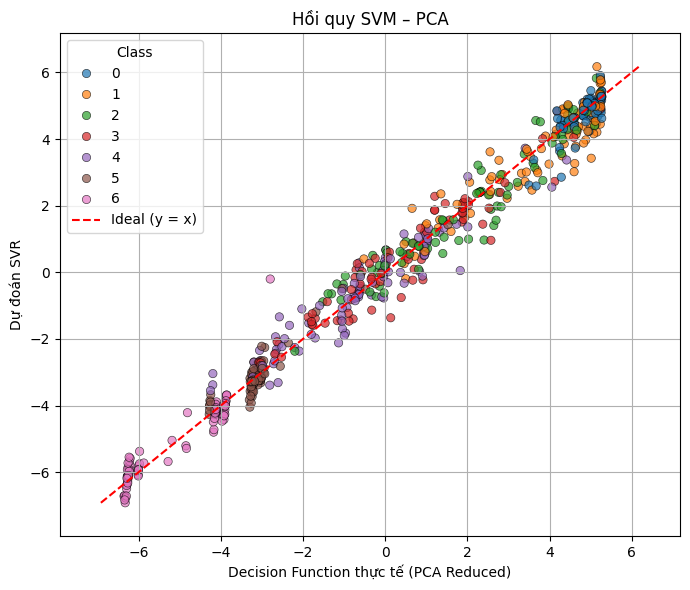

In [154]:
svm_pca = SVC(kernel="rbf", C=1, class_weight="balanced", random_state=42)
svm_pca.fit(X_train_pca, y_train.values.ravel())
mse_pca, r2_pca = svm_regression_on_decision_values(
    X_train_pca, X_test_pca, y_train, y_test, svm_pca, "PCA"
)

Thực hiện trên tập dữ liệu LDA


Shape decision_function: (1477, 7)
Áp dụng PCA cho decision_function...

[Hồi quy SVM] - LDA
MSE : 0.0611
R²  : 0.9971


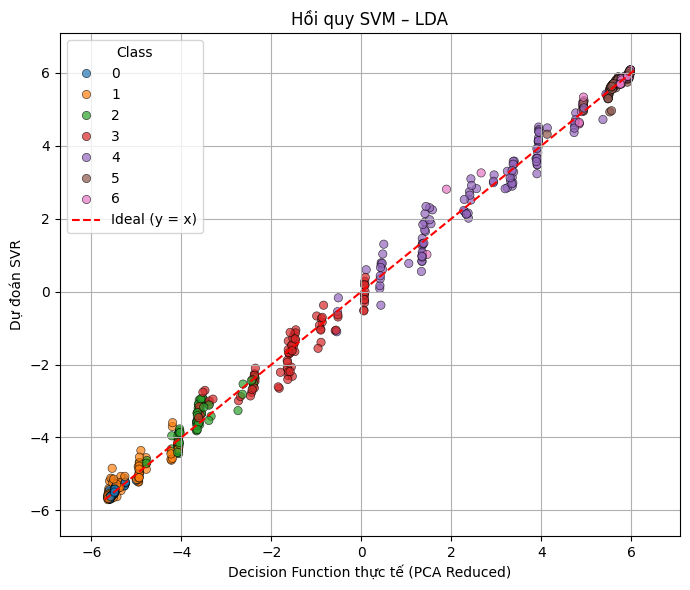

In [155]:
svm_lda = SVC(kernel="rbf", C=1, class_weight="balanced", random_state=42)
svm_lda.fit(X_train_lda, y_train.values.ravel())

mse_lda, r2_lda = svm_regression_on_decision_values(
    X_train_lda, X_test_lda, y_train, y_test, svm_lda, "LDA"
)

So sánh kết quả thực hiện trên 3 tệp dữ liệu

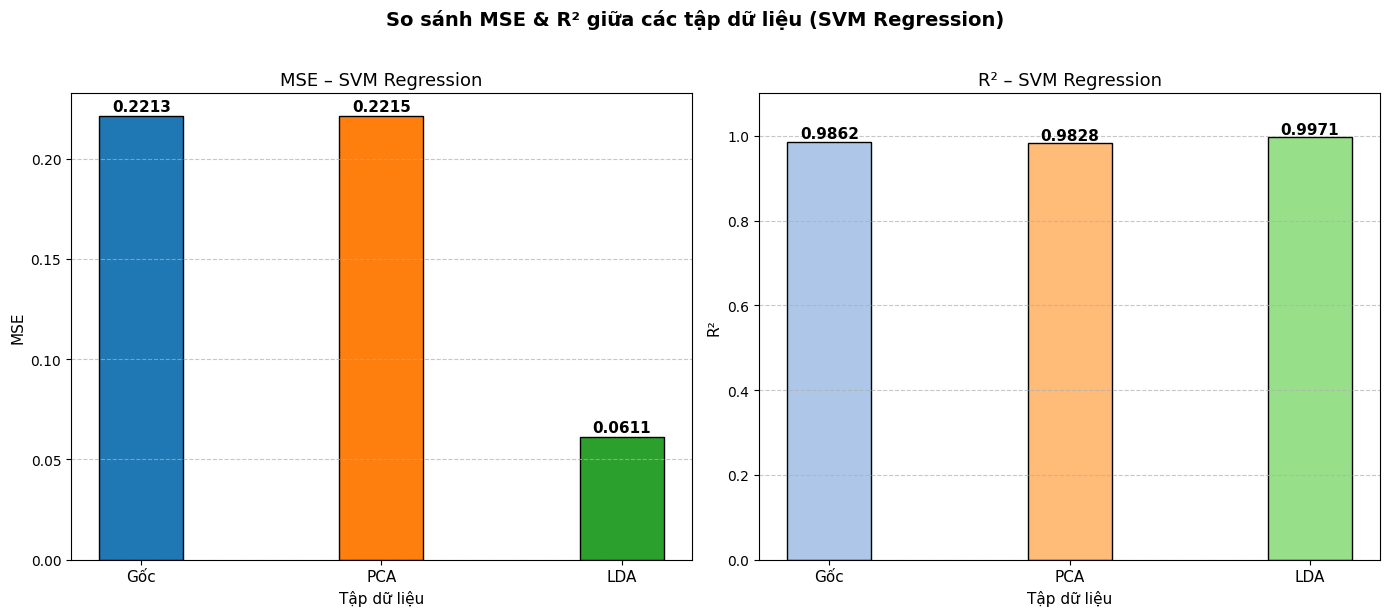

In [156]:
import numpy as np
import matplotlib.pyplot as plt

def plot_svm_regression_performance(results_dict):
    datasets   = list(results_dict.keys())
    mse_scores = [results_dict[k][0] for k in datasets]
    r2_scores  = [results_dict[k][1] for k in datasets]

    x     = np.arange(len(datasets))
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Biểu đồ MSE
    colors_mse = ['#1f77b4', '#ff7f0e', '#2ca02c']
    bars1 = ax1.bar(x, mse_scores, width, color=colors_mse, edgecolor='black')

    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, yval + 0.001,
                 f'{yval:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax1.set_title('MSE – SVM Regression', fontsize=13)
    ax1.set_xlabel('Tập dữ liệu', fontsize=11)
    ax1.set_ylabel('MSE', fontsize=11)
    ax1.set_xticks(x)
    ax1.set_xticklabels(datasets, fontsize=11)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Biểu đồ R²
    colors_r2 = ['#aec7e8', '#ffbb78', '#98df8a']
    bars2 = ax2.bar(x, r2_scores, width, color=colors_r2,
                    edgecolor='black')

    for bar in bars2:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, yval + 0.001,
                 f'{yval:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax2.set_title('R² – SVM Regression', fontsize=13)
    ax2.set_xlabel('Tập dữ liệu', fontsize=11)
    ax2.set_ylabel('R²', fontsize=11)
    ax2.set_xticks(x)
    ax2.set_xticklabels(datasets, fontsize=11)
    ax2.set_ylim(0, 1.1)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle('So sánh MSE & R² giữa các tập dữ liệu (SVM Regression)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

svm_reg_results = {
    'Gốc': (mse_goc, r2_goc),
    'PCA':  (mse_pca, r2_pca),
    'LDA':  (mse_lda, r2_lda),
}

plot_svm_regression_performance(svm_reg_results)

##Softmax Regression


Trong phần này, nhóm thực hiện chuyển đổi mô hình Softmax Classification sang dạng hồi quy nhằm khai thác thông tin xác suất liên tục từ mô hình phân loại thay vì chỉ sử dụng nhãn dự đoán rời rạc. Phương pháp được áp dụng trên bộ dữ liệu Obesity sau khi dữ liệu đã được chuẩn hóa và giảm chiều bằng các kỹ thuật PCA và LDA.

Mô hình sử dụng là Multinomial Logistic Regression (Softmax Regression), trong đó đầu ra của mô hình không chỉ là nhãn lớp dự đoán mà còn bao gồm phân phối xác suất của từng lớp thông qua hàm `predict_proba()`. Với mỗi mẫu dữ liệu, mô hình trả về xác suất thuộc về từng mức độ béo phì khác nhau.

Để chuyển bài toán phân loại sang hồi quy, nhóm sử dụng giá trị kỳ vọng (expected value) của phân phối xác suất đầu ra. Cụ thể, nếu:

* (P(y=k|x)) là xác suất mẫu thuộc lớp (k),
* (k) là giá trị số đại diện cho lớp,

thì giá trị hồi quy được tính theo công thức:

$$
\hat{y} = \sum_{k=0}^{K-1} k \cdot P(y=k \mid x)
$$

Kết quả thu được là một giá trị liên tục phản ánh mức độ của lớp dự đoán thay vì một nhãn phân loại rời rạc. Phương pháp này đặc biệt phù hợp với bài toán Obesity vì các lớp dữ liệu có tính thứ tự (ordinal), ví dụ từ “Insufficient Weight” đến “Obesity III”.

Sau khi chuyển sang dạng hồi quy, nhóm đánh giá hiệu quả mô hình bằng các chỉ số:

* Mean Squared Error (MSE)
* Hệ số xác định (R^2)

Ngoài ra, nhóm trực quan hóa mối quan hệ giữa nhãn thực tế và giá trị dự đoán liên tục thông qua biểu đồ scatter plot cùng đường tham chiếu lý tưởng (y=x). Các điểm dữ liệu nằm càng gần đường lý tưởng cho thấy mô hình hồi quy hoạt động càng chính xác.

Thông qua phương pháp này, nhóm có thể đánh giá khả năng của Softmax Regression trong việc biểu diễn mối quan hệ liên tục giữa các mức độ béo phì, đồng thời tận dụng được toàn bộ thông tin xác suất mà mô hình phân loại cung cấp.


In [157]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [158]:
y_train = pd.read_csv("/content/y_train.csv")
y_test = pd.read_csv("/content/y_test.csv")
X_train_orig = pd.read_csv("/content/X_train_scaled.csv")
X_test_orig  = pd.read_csv("/content/X_test_scaled.csv")
X_train_pca = pd.read_csv("/content/X_train_pca.csv")
X_test_pca = pd.read_csv("/content/X_test_pca.csv")
X_train_lda = pd.read_csv("/content/X_train_lda_5.csv")
X_test_lda = pd.read_csv("/content/X_test_lda_5.csv")

for df in [X_train_pca, X_test_pca, X_train_lda, X_test_lda]:
    if 'NObeyesdad' in df.columns:
        df.drop('NObeyesdad', axis=1, inplace=True)

def softmax_as_regression(X_train, X_test, y_train, y_test, lr_model, dataset_name):

    y_train_1d = y_train.values.ravel()
    y_test_1d  = y_test.values.ravel()

    proba   = lr_model.predict_proba(X_test)
    classes = lr_model.classes_
    y_pred  = proba @ classes

    mse = mean_squared_error(y_test_1d, y_pred)
    r2  = r2_score(y_test_1d, y_pred)

    print(f"\n[Softmax → Hồi quy] - {dataset_name}")
    print(f"MSE : {mse:.4f}")
    print(f"R²  : {r2:.4f}")

    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        x=y_test_1d, y=y_pred,
        hue=y_test_1d, palette='tab10',
        alpha=0.7, edgecolor='k'
    )
    min_val = min(y_test_1d.min(), y_pred.min())
    max_val = max(y_test_1d.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val],
             linestyle='--', color='red', label='Ideal (y = x)')
    plt.xlim(min_val - 0.5, max_val + 0.5)
    plt.ylim(min_val - 0.5, max_val + 0.5)
    plt.xlabel("Nhãn thực tế (mã số)")
    plt.ylabel("Giá trị dự đoán liên tục")
    plt.title(f"Softmax → Hồi quy – {dataset_name}")
    plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return mse, r2

Thực hiện trên tệp dữ liệu gốc


[Softmax → Hồi quy] - Dữ liệu gốc
MSE : 0.0965
R²  : 0.9762


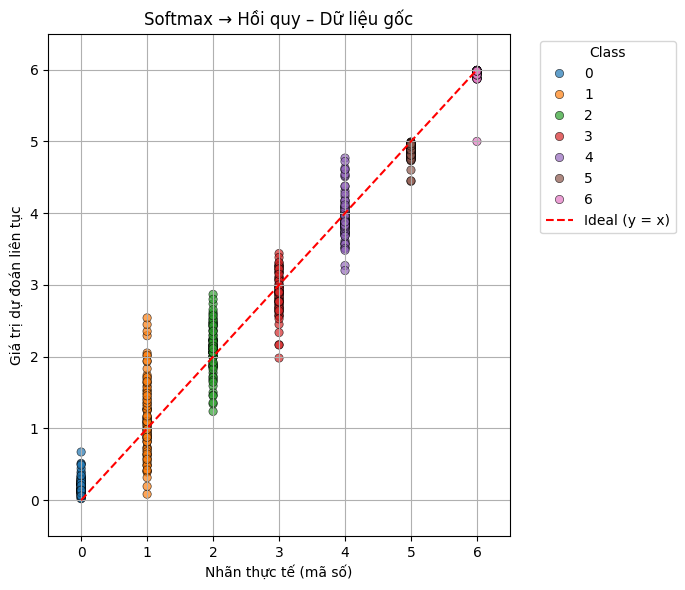

In [159]:
lr_orig = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                              max_iter=1000, random_state=42)
lr_orig.fit(X_train_orig, y_train.values.ravel())

mse_goc, r2_goc = softmax_as_regression(
    X_train_orig, X_test_orig, y_train, y_test, lr_orig, "Dữ liệu gốc"
)

Thực hiện trên tệp dữ liệu PCA


[Softmax → Hồi quy] - PCA
MSE : 0.5657
R²  : 0.8603


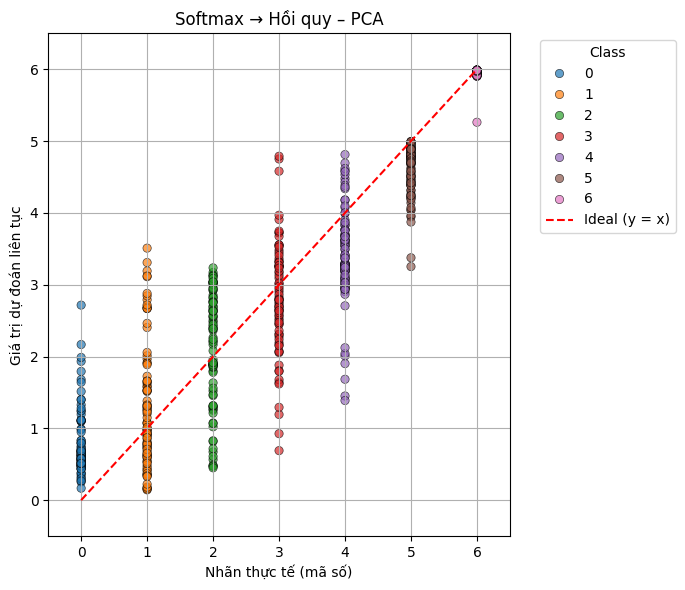

In [160]:
lr_pca = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                             max_iter=1000, random_state=42)
lr_pca.fit(X_train_pca, y_train.values.ravel())

mse_pca, r2_pca = softmax_as_regression(
    X_train_pca, X_test_pca, y_train, y_test, lr_pca, "PCA"
)

Thực hiện trên tệp dữ liệu LDA


[Softmax → Hồi quy] - LDA
MSE : 0.0573
R²  : 0.9859


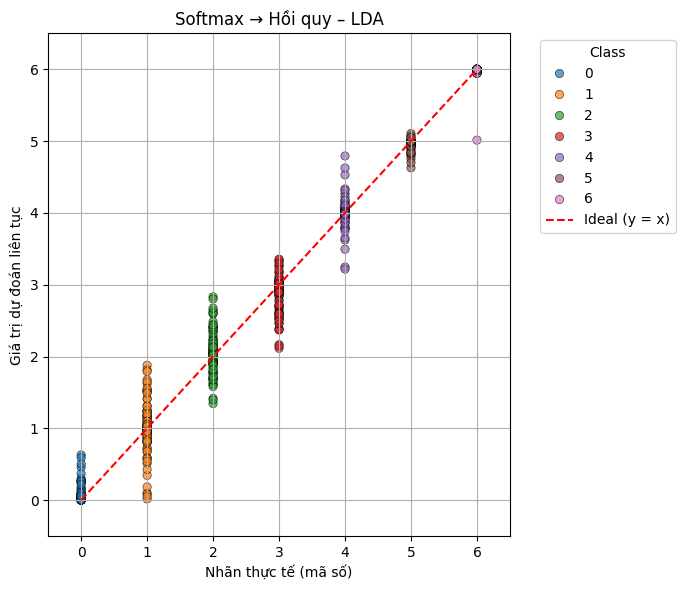

In [161]:
lr_lda = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                             max_iter=1000, random_state=42)
lr_lda.fit(X_train_lda, y_train.values.ravel())

mse_lda, r2_lda = softmax_as_regression(
    X_train_lda, X_test_lda, y_train, y_test, lr_lda, "LDA"
)

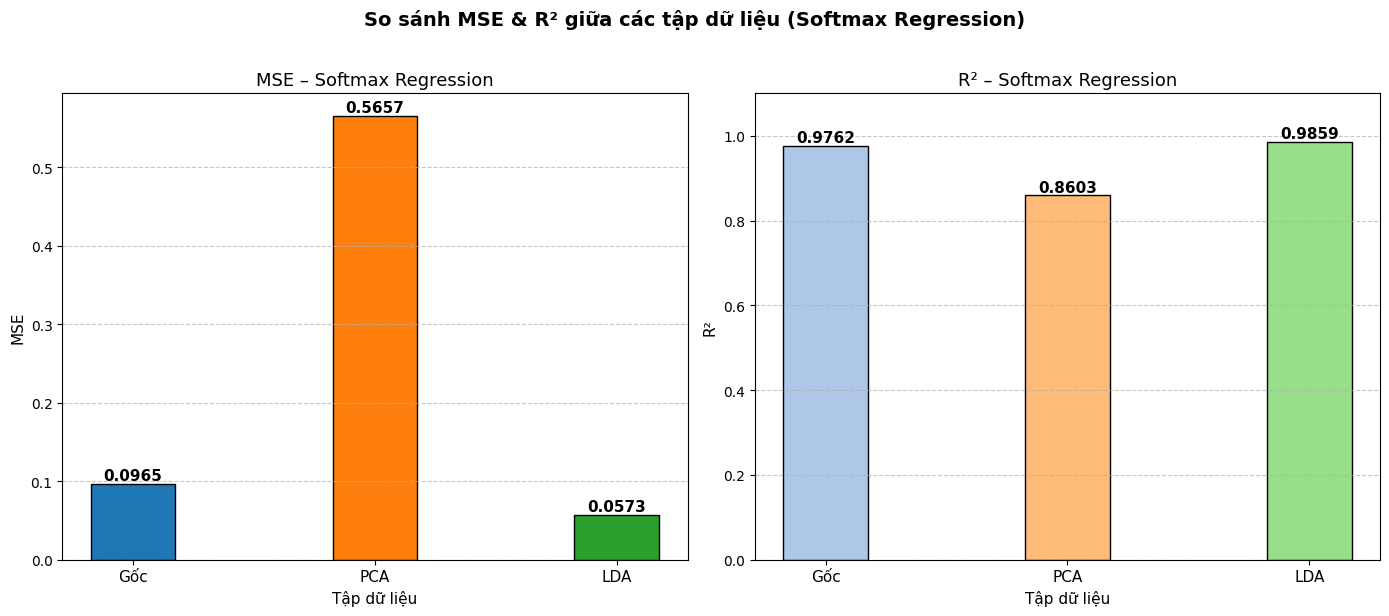

In [162]:
def plot_softmax_regression_performance(results_dict):

    datasets   = list(results_dict.keys())
    mse_scores = [results_dict[k][0] for k in datasets]
    r2_scores  = [results_dict[k][1] for k in datasets]

    x     = np.arange(len(datasets))
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    colors_mse = ['#1f77b4', '#ff7f0e', '#2ca02c']
    bars1 = ax1.bar(x, mse_scores, width, color=colors_mse, edgecolor='black')
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, yval + 0.001,
                 f'{yval:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax1.set_title('MSE – Softmax Regression', fontsize=13)
    ax1.set_xlabel('Tập dữ liệu', fontsize=11)
    ax1.set_ylabel('MSE', fontsize=11)
    ax1.set_xticks(x)
    ax1.set_xticklabels(datasets, fontsize=11)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    colors_r2 = ['#aec7e8', '#ffbb78', '#98df8a']
    bars2 = ax2.bar(x, r2_scores, width, color=colors_r2, edgecolor='black')
    for bar in bars2:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, yval + 0.001,
                 f'{yval:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.set_title('R² – Softmax Regression', fontsize=13)
    ax2.set_xlabel('Tập dữ liệu', fontsize=11)
    ax2.set_ylabel('R²', fontsize=11)
    ax2.set_xticks(x)
    ax2.set_xticklabels(datasets, fontsize=11)
    ax2.set_ylim(0, 1.1)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle('So sánh MSE & R² giữa các tập dữ liệu (Softmax Regression)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# ← ngoài hàm, không thụt lề
softmax_results = {
    'Gốc': (mse_goc, r2_goc),
    'PCA':  (mse_pca, r2_pca),
    'LDA':  (mse_lda, r2_lda),
}

plot_softmax_regression_performance(softmax_results)

 Đối với mô hình SVM hồi quy (SVR), phương pháp giảm chiều LDA cho kết quả tốt nhất với MSE thấp nhất đạt 0.0572 và R² cao nhất đạt 0.9859. Trong khi đó, PCA cho kết quả kém nhất với MSE lên tới 0.5657 và R² chỉ đạt 0.8603, cho thấy PCA làm giảm đáng kể khả năng hồi quy của SVR.

 Đối với mô hình Softmax hồi quy, LDA cũng cho kết quả vượt trội với MSE thấp nhất đạt 0.0611 và R² cao nhất đạt 0.9971. Dữ liệu gốc và PCA cho kết quả tương đương nhau với MSE lần lượt là 0.2213 và 0.2215, R² lần lượt là 0.9862 và 0.9828, cho thấy PCA hầu như không cải thiện hiệu suất so với dữ liệu gốc đối với mô hình này.

 Phương pháp giảm chiều LDA một lần nữa khẳng định hiệu quả vượt trội so với PCA và dữ liệu gốc trên cả hai mô hình hồi quy. LDA giúp giảm mạnh sai số MSE và nâng cao đáng kể hệ số R², chứng tỏ khả năng giữ lại thông tin hồi quy quan trọng tốt hơn so với PCA.

 Mô hình tốt nhất: Tổ hợp Softmax hồi quy + LDA được xác định là mô hình tốt nhất trong thí nghiệm hồi quy, với MSE đạt 0.0611 và R² đạt 0.9971, cho thấy mô hình này có khả năng dự đoán chính xác và giải thích tốt phương sai của dữ liệu.
